In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw data directory
RAW_DATA = PROJECT_ROOT / "data" / "raw"

# Dataset paths
accounts_path = RAW_DATA / "accounts.csv"
transactions_path = RAW_DATA / "transaction.csv"
alerts_path = RAW_DATA / "alerts.csv"

# Load datasets
accounts_df = pd.read_csv(accounts_path)
transactions_df = pd.read_csv(transactions_path)
alerts_df = pd.read_csv(alerts_path)

In [9]:
print("Accounts:")
print(accounts_df.shape)

print("\nTransactions:")
print(transactions_df.shape)

print("\nAlerts:")
print(alerts_df.shape)

Accounts:
(1000, 7)

Transactions:
(117533, 8)

Alerts:
(175, 9)


In [10]:
print("Accounts columns:")
print(accounts_df.columns.tolist())

print("\nTransactions columns:")
print(transactions_df.columns.tolist())

print("\nAlerts columns:")
print(alerts_df.columns.tolist())

Accounts columns:
['ACCOUNT_ID', 'CUSTOMER_ID', 'INIT_BALANCE', 'COUNTRY', 'ACCOUNT_TYPE', 'IS_FRAUD', 'TX_BEHAVIOR_ID']

Transactions columns:
['TX_ID', 'SENDER_ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID', 'TX_TYPE', 'TX_AMOUNT', 'TIMESTAMP', 'IS_FRAUD', 'ALERT_ID']

Alerts columns:
['ALERT_ID', 'ALERT_TYPE', 'IS_FRAUD', 'TX_ID', 'SENDER_ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID', 'TX_TYPE', 'TX_AMOUNT', 'TIMESTAMP']


In [11]:
print("===== ACCOUNTS =====")
accounts_df.info()

print("\n===== TRANSACTIONS =====")
transactions_df.info()

print("\n===== ALERTS =====")
alerts_df.info()

===== ACCOUNTS =====
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      1000 non-null   int64  
 1   CUSTOMER_ID     1000 non-null   str    
 2   INIT_BALANCE    1000 non-null   float64
 3   COUNTRY         1000 non-null   str    
 4   ACCOUNT_TYPE    1000 non-null   str    
 5   IS_FRAUD        1000 non-null   bool   
 6   TX_BEHAVIOR_ID  1000 non-null   int64  
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 48.0 KB

===== TRANSACTIONS =====
<class 'pandas.DataFrame'>
RangeIndex: 117533 entries, 0 to 117532
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TX_ID                117533 non-null  int64  
 1   SENDER_ACCOUNT_ID    117533 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  117533 non-null  int64  
 3   TX_TYPE              117533

In [12]:
print("Missing values:")
print("\nAccounts:")
print(accounts_df.isnull().sum())

print("\nTransactions:")
print(transactions_df.isnull().sum())

print("\nAlerts:")
print(alerts_df.isnull().sum())

Missing values:

Accounts:
ACCOUNT_ID        0
CUSTOMER_ID       0
INIT_BALANCE      0
COUNTRY           0
ACCOUNT_TYPE      0
IS_FRAUD          0
TX_BEHAVIOR_ID    0
dtype: int64

Transactions:
TX_ID                  0
SENDER_ACCOUNT_ID      0
RECEIVER_ACCOUNT_ID    0
TX_TYPE                0
TX_AMOUNT              0
TIMESTAMP              0
IS_FRAUD               0
ALERT_ID               0
dtype: int64

Alerts:
ALERT_ID               0
ALERT_TYPE             0
IS_FRAUD               0
TX_ID                  0
SENDER_ACCOUNT_ID      0
RECEIVER_ACCOUNT_ID    0
TX_TYPE                0
TX_AMOUNT              0
TIMESTAMP              0
dtype: int64


In [13]:
print("Duplicate rows:")
print("Accounts:", accounts_df.duplicated().sum())
print("Transactions:", transactions_df.duplicated().sum())
print("Alerts:", alerts_df.duplicated().sum())

Duplicate rows:
Accounts: 0
Transactions: 0
Alerts: 0


In [14]:
print("Duplicate ACCOUNT_IDs:", accounts_df["ACCOUNT_ID"].duplicated().sum())
print("Duplicate TX_IDs:", transactions_df["TX_ID"].duplicated().sum())
print("Duplicate ALERT_IDs:", alerts_df["ALERT_ID"].duplicated().sum())

Duplicate ACCOUNT_IDs: 0
Duplicate TX_IDs: 0
Duplicate ALERT_IDs: 135


In [15]:
# ============================================================
# ALERT_ID ANALYSIS
# ============================================================
# An ALERT_ID may appear more than once in the Alerts dataset.
# We need to understand whether one alert can be associated
# with multiple transactions.
# ============================================================

# Count how many times each ALERT_ID appears
alert_counts = alerts_df["ALERT_ID"].value_counts()

# Display the total number of unique alert IDs
print("Number of unique ALERT_IDs:", alerts_df["ALERT_ID"].nunique())

# Display the total number of records in the Alerts dataset
print("Total alert records:", len(alerts_df))

# Display the 10 most frequently occurring ALERT_IDs
print("\nMost frequent ALERT_IDs:")
print(alert_counts.head(10))

Number of unique ALERT_IDs: 40
Total alert records: 175

Most frequent ALERT_IDs:
ALERT_ID
23    5
29    5
37    5
30    5
33    5
39    5
32    5
38    5
22    5
28    5
Name: count, dtype: int64


In [16]:
# ============================================================
# ALERT_ID → TRANSACTION RELATIONSHIP
# ============================================================
# Here we check how many transactions are associated with
# each ALERT_ID.
#
# If an ALERT_ID appears multiple times, it may indicate that
# one alert is related to multiple transactions.
# ============================================================

# Group the Alerts dataset by ALERT_ID
# and count the number of TX_ID records associated with each alert
transactions_per_alert = (
    alerts_df.groupby("ALERT_ID")["TX_ID"]
    .count()
    .sort_values(ascending=False)
)

# Display the 10 alerts associated with the most transactions
print("Number of transactions associated with each ALERT_ID:")
print(transactions_per_alert.head(10))

Number of transactions associated with each ALERT_ID:
ALERT_ID
20    5
21    5
23    5
24    5
25    5
27    5
28    5
29    5
30    5
31    5
Name: TX_ID, dtype: int64


In [17]:
# ============================================================
# DISTRIBUTION OF TRANSACTIONS PER ALERT
# ============================================================
# We already know that some ALERT_IDs are associated with
# multiple transactions.
#
# Now we want to see the complete distribution:
# How many alerts have 1 transaction?
# How many have 2 transactions?
# How many have 5 transactions?
#
# This helps us understand the structure of the Alerts dataset.
# ============================================================

# Count the number of transactions associated with each ALERT_ID
transactions_per_alert = (
    alerts_df.groupby("ALERT_ID")["TX_ID"]
    .count()
)

# Count how many ALERT_IDs have each transaction count
alert_distribution = transactions_per_alert.value_counts().sort_index()

# Display the distribution
print("Number of transactions per ALERT_ID:")
print(alert_distribution)

Number of transactions per ALERT_ID:
TX_ID
1     1
3     1
4    19
5    19
Name: count, dtype: int64


In [18]:
# ============================================================
# CHECK WHETHER ALERT_ID AND TX_ID HAVE A ONE-TO-MANY RELATION
# ============================================================
# An ALERT_ID can appear multiple times, but TX_ID should
# ideally identify an individual transaction.
#
# We check whether the same TX_ID appears more than once
# inside the Alerts dataset.
# ============================================================

# Count duplicate TX_IDs in the Alerts dataset
duplicate_alert_tx_ids = alerts_df["TX_ID"].duplicated().sum()

print("Duplicate TX_IDs in Alerts:", duplicate_alert_tx_ids)

# Display the number of unique transactions represented
# in the Alerts dataset
print("Unique TX_IDs in Alerts:", alerts_df["TX_ID"].nunique())

Duplicate TX_IDs in Alerts: 0
Unique TX_IDs in Alerts: 175


In [19]:
# ============================================================
# FRAUD DISTRIBUTION
# ============================================================
# Our AML Guard system is ultimately interested in detecting
# suspicious or fraudulent financial activity.
#
# Therefore, we need to understand how many records are
# labeled as fraud and how many are labeled as legitimate.
# ============================================================


# ------------------------------------------------------------
# 1. Fraud distribution in Accounts
# ------------------------------------------------------------

print("===== ACCOUNTS FRAUD DISTRIBUTION =====")

# Count the number of fraudulent and non-fraudulent accounts
print(accounts_df["IS_FRAUD"].value_counts())

# Convert the counts into percentages
print("\nAccounts fraud percentage:")
print(accounts_df["IS_FRAUD"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 2. Fraud distribution in Transactions
# ------------------------------------------------------------

print("\n===== TRANSACTIONS FRAUD DISTRIBUTION =====")

# Count the number of fraudulent and non-fraudulent transactions
print(transactions_df["IS_FRAUD"].value_counts())

# Convert the counts into percentages
print("\nTransactions fraud percentage:")
print(transactions_df["IS_FRAUD"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 3. Fraud distribution in Alerts
# ------------------------------------------------------------

print("\n===== ALERTS FRAUD DISTRIBUTION =====")

# Count the number of fraudulent and non-fraudulent alerts
print(alerts_df["IS_FRAUD"].value_counts())

# Convert the counts into percentages
print("\nAlerts fraud percentage:")
print(alerts_df["IS_FRAUD"].value_counts(normalize=True) * 100)

===== ACCOUNTS FRAUD DISTRIBUTION =====
IS_FRAUD
False    838
True     162
Name: count, dtype: int64

Accounts fraud percentage:
IS_FRAUD
False    83.8
True     16.2
Name: proportion, dtype: float64

===== TRANSACTIONS FRAUD DISTRIBUTION =====
IS_FRAUD
False    117358
True        175
Name: count, dtype: int64

Transactions fraud percentage:
IS_FRAUD
False    99.851106
True      0.148894
Name: proportion, dtype: float64

===== ALERTS FRAUD DISTRIBUTION =====
IS_FRAUD
True    175
Name: count, dtype: int64

Alerts fraud percentage:
IS_FRAUD
True    100.0
Name: proportion, dtype: float64


In [20]:
# ============================================================
# VERIFY FRAUDULENT TRANSACTIONS AND ALERTS
# ============================================================
# We discovered that:
#
#   Fraudulent transactions = 175
#   Alert records            = 175
#
# Now we will verify whether the TX_ID values of the
# fraudulent transactions are exactly the same as the
# TX_ID values present in the Alerts dataset.
# ============================================================


# Get the TX_IDs of all fraudulent transactions
fraud_transaction_ids = set(
    transactions_df.loc[
        transactions_df["IS_FRAUD"] == True,
        "TX_ID"
    ]
)


# Get all TX_IDs present in the Alerts dataset
alert_transaction_ids = set(
    alerts_df["TX_ID"]
)


# Compare the two sets
print("Number of fraudulent transaction IDs:",
      len(fraud_transaction_ids))

print("Number of alert transaction IDs:",
      len(alert_transaction_ids))


# Check whether both sets contain exactly the same TX_IDs
print(
    "\nDo fraudulent transactions exactly match alert transactions?",
    fraud_transaction_ids == alert_transaction_ids
)

Number of fraudulent transaction IDs: 175
Number of alert transaction IDs: 175

Do fraudulent transactions exactly match alert transactions? True


In [21]:
# ============================================================
# TRANSACTION TYPE DISTRIBUTION
# ============================================================
# The TX_TYPE column tells us what type of transaction
# occurred.
#
# We will examine:
#   1. Which transaction types exist?
#   2. How frequently does each type occur?
#   3. What percentage of all transactions belongs to
#      each transaction type?
# ============================================================


# Count the number of transactions for each transaction type
transaction_type_counts = transactions_df["TX_TYPE"].value_counts()

print("===== TRANSACTION TYPE COUNTS =====")
print(transaction_type_counts)


# Calculate the percentage of each transaction type
transaction_type_percentage = (
    transactions_df["TX_TYPE"]
    .value_counts(normalize=True)
    * 100
)

print("\n===== TRANSACTION TYPE PERCENTAGES =====")
print(transaction_type_percentage)

===== TRANSACTION TYPE COUNTS =====
TX_TYPE
TRANSFER    117533
Name: count, dtype: int64

===== TRANSACTION TYPE PERCENTAGES =====
TX_TYPE
TRANSFER    100.0
Name: proportion, dtype: float64


In [22]:
# ============================================================
# FRAUD BY TRANSACTION TYPE
# ============================================================
# Now we want to know whether certain transaction types
# contain more fraudulent transactions than others.
#
# This can be useful later when creating features for our
# AML/fraud detection model.
# ============================================================


# Select only fraudulent transactions
fraud_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == True
]


# Count fraudulent transactions for each transaction type
fraud_by_type = fraud_transactions["TX_TYPE"].value_counts()

print("===== FRAUDULENT TRANSACTIONS BY TYPE =====")
print(fraud_by_type)

===== FRAUDULENT TRANSACTIONS BY TYPE =====
TX_TYPE
TRANSFER    175
Name: count, dtype: int64


In [23]:
# ============================================================
# TRANSACTION AMOUNT ANALYSIS
# ============================================================
# TX_AMOUNT represents the amount of money involved in each
# transaction.
#
# We will calculate basic statistical measures to understand
# the distribution of transaction amounts.
# ============================================================


print("===== OVERALL TRANSACTION AMOUNTS =====")

# Calculate and display descriptive statistics
print(transactions_df["TX_AMOUNT"].describe())

===== OVERALL TRANSACTION AMOUNTS =====
count    1.175330e+05
mean     2.130113e+04
std      2.504431e+05
min      0.000000e+00
25%      3.451000e+01
50%      1.681300e+02
75%      4.624500e+02
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64


In [24]:
# ============================================================
# TRANSACTION AMOUNT: FRAUD VS NON-FRAUD
# ============================================================
# We now compare transaction amounts between:
#
#   1. Legitimate transactions
#   2. Fraudulent transactions
#
# This can help us determine whether transaction amount
# could be a useful feature for fraud detection.
# ============================================================


# Separate legitimate and fraudulent transactions
legitimate_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == False
]

fraud_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == True
]


# Display statistics for legitimate transactions
print("===== LEGITIMATE TRANSACTIONS =====")
print(legitimate_transactions["TX_AMOUNT"].describe())


# Display statistics for fraudulent transactions
print("\n===== FRAUDULENT TRANSACTIONS =====")
print(fraud_transactions["TX_AMOUNT"].describe())

===== LEGITIMATE TRANSACTIONS =====
count    1.173580e+05
mean     2.133288e+04
std      2.506284e+05
min      0.000000e+00
25%      3.511000e+01
50%      1.681300e+02
75%      4.624500e+02
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64

===== FRAUDULENT TRANSACTIONS =====
count    175.000000
mean       9.877600
std        6.022304
min        2.570000
25%        3.945000
50%       10.970000
75%       15.710000
max       19.960000
Name: TX_AMOUNT, dtype: float64


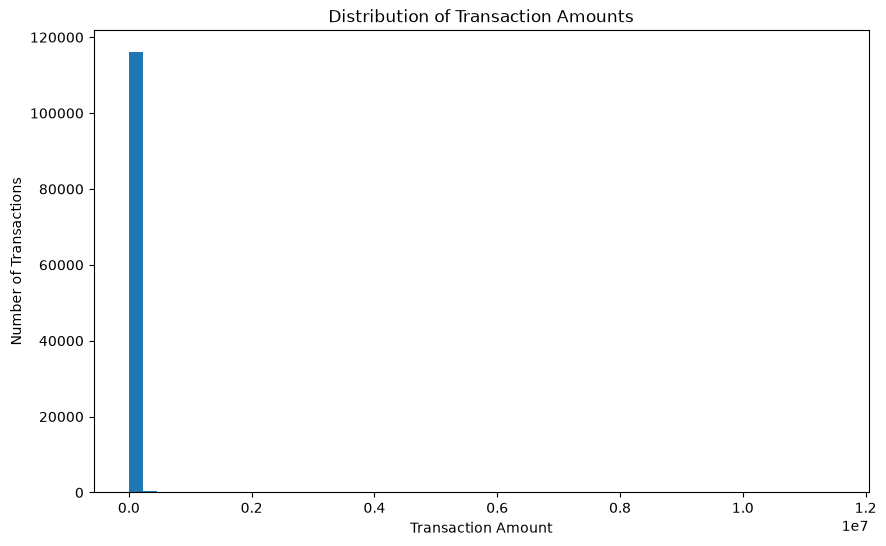

In [25]:
# ============================================================
# TRANSACTION AMOUNT DISTRIBUTION
# ============================================================
# Transaction amounts are highly skewed because a small number
# of transactions have very large values.
#
# A histogram will help us visually understand how transaction
# amounts are distributed.
# ============================================================

plt.figure(figsize=(10, 6))

# Plot the distribution of all transaction amounts
plt.hist(
    transactions_df["TX_AMOUNT"],
    bins=50
)

# Add labels and title
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Transaction Amounts")

# Display the plot
plt.show()

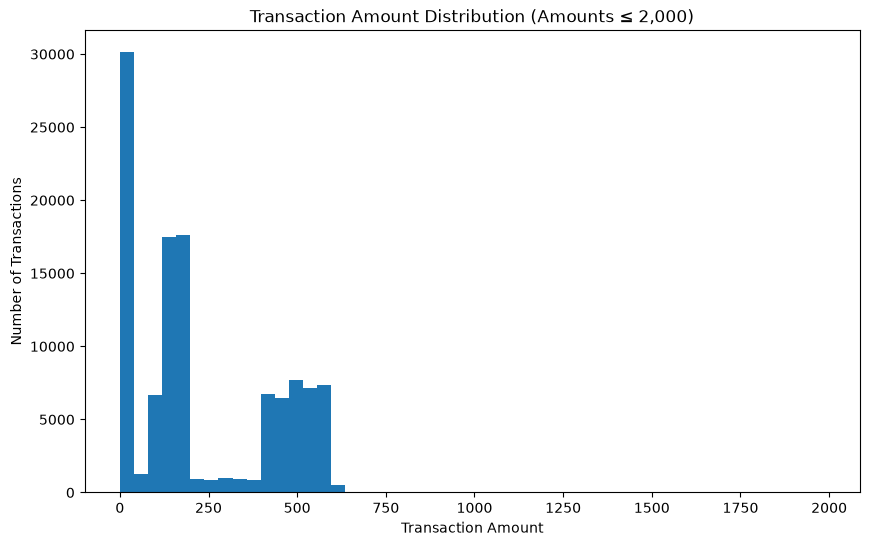

In [26]:
# ============================================================
# TRANSACTION AMOUNT DISTRIBUTION — SMALLER RANGE
# ============================================================
# Most transactions are relatively small, but a few extremely
# large transactions make the overall distribution difficult
# to see.
#
# Here we display only transactions up to 2,000 so that we can
# better observe the distribution of the majority of transactions.
# ============================================================

plt.figure(figsize=(10, 6))

# Select transactions with amounts up to 2,000
small_transactions = transactions_df[
    transactions_df["TX_AMOUNT"] <= 2000
]

# Plot the selected transaction amounts
plt.hist(
    small_transactions["TX_AMOUNT"],
    bins=50
)

# Add labels and title
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution (Amounts ≤ 2,000)")

# Display the plot
plt.show()

In [27]:
# ============================================================
# TRANSACTION AMOUNT RANGES
# ============================================================
# Instead of looking only at a graph, we divide transactions
# into different amount ranges.
#
# This allows us to see exactly how many transactions fall
# into each range.
# ============================================================


# Define transaction amount ranges
amount_bins = [
    -1,
    10,
    50,
    100,
    500,
    1000,
    5000,
    10000,
    50000,
    100000,
    float("inf")
]


# Give each range a readable label
amount_labels = [
    "0 - 10",
    "10 - 50",
    "50 - 100",
    "100 - 500",
    "500 - 1,000",
    "1,000 - 5,000",
    "5,000 - 10,000",
    "10,000 - 50,000",
    "50,000 - 100,000",
    "100,000+"
]


# Assign every transaction to an amount range
transaction_amount_ranges = pd.cut(
    transactions_df["TX_AMOUNT"],
    bins=amount_bins,
    labels=amount_labels
)


# Count transactions in each range
amount_range_counts = transaction_amount_ranges.value_counts(
    sort=False
)


# Display the results
print("===== TRANSACTION AMOUNT RANGES =====")
print(amount_range_counts)


# Calculate percentages
amount_range_percentages = (
    transaction_amount_ranges.value_counts(
        sort=False,
        normalize=True
    ) * 100
)


print("\n===== TRANSACTION AMOUNT RANGE PERCENTAGES =====")
print(amount_range_percentages)

===== TRANSACTION AMOUNT RANGES =====
TX_AMOUNT
0 - 10               7160
10 - 50             23858
50 - 100              641
100 - 500           64438
500 - 1,000         17650
1,000 - 5,000         437
5,000 - 10,000        233
10,000 - 50,000       774
50,000 - 100,000      368
100,000+             1974
Name: count, dtype: int64

===== TRANSACTION AMOUNT RANGE PERCENTAGES =====
TX_AMOUNT
0 - 10               6.091906
10 - 50             20.298980
50 - 100             0.545379
100 - 500           54.825453
500 - 1,000         15.017059
1,000 - 5,000        0.371810
5,000 - 10,000       0.198242
10,000 - 50,000      0.658538
50,000 - 100,000     0.313104
100,000+             1.679528
Name: proportion, dtype: float64


In [28]:
# ============================================================
# FRAUDULENT TRANSACTIONS BY AMOUNT RANGE
# ============================================================
# We previously divided all transactions into different
# amount ranges.
#
# Now we perform the same analysis only on fraudulent
# transactions.
#
# This will help us understand whether fraudulent transactions
# are concentrated in particular amount ranges.
# ============================================================


# Select only fraudulent transactions
fraud_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == True
]


# Divide fraudulent transactions into the same amount ranges
fraud_amount_ranges = pd.cut(
    fraud_transactions["TX_AMOUNT"],
    bins=amount_bins,
    labels=amount_labels
)


# Count fraudulent transactions in each amount range
fraud_amount_range_counts = (
    fraud_amount_ranges
    .value_counts(sort=False)
)


# Display the results
print("===== FRAUDULENT TRANSACTIONS BY AMOUNT RANGE =====")
print(fraud_amount_range_counts)


# Calculate percentages
fraud_amount_range_percentages = (
    fraud_amount_ranges
    .value_counts(sort=False, normalize=True)
    * 100
)


print("\n===== FRAUDULENT TRANSACTIONS BY AMOUNT RANGE (%) =====")
print(fraud_amount_range_percentages)

===== FRAUDULENT TRANSACTIONS BY AMOUNT RANGE =====
TX_AMOUNT
0 - 10              79
10 - 50             96
50 - 100             0
100 - 500            0
500 - 1,000          0
1,000 - 5,000        0
5,000 - 10,000       0
10,000 - 50,000      0
50,000 - 100,000     0
100,000+             0
Name: count, dtype: int64

===== FRAUDULENT TRANSACTIONS BY AMOUNT RANGE (%) =====
TX_AMOUNT
0 - 10              45.142857
10 - 50             54.857143
50 - 100             0.000000
100 - 500            0.000000
500 - 1,000          0.000000
1,000 - 5,000        0.000000
5,000 - 10,000       0.000000
10,000 - 50,000      0.000000
50,000 - 100,000     0.000000
100,000+             0.000000
Name: proportion, dtype: float64


In [29]:
# ============================================================
# FRAUDULENT TRANSACTIONS BY SENDER ACCOUNT
# ============================================================
# We previously discovered that all 175 fraudulent transactions
# have transaction amounts below 50.
#
# Now we want to identify the accounts that SENT these
# fraudulent transactions.
#
# This helps us understand whether fraud is concentrated
# among a small number of sender accounts or spread across
# many different accounts.
# ============================================================


# Select only fraudulent transactions
fraud_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == True
]


# Count how many fraudulent transactions each sender account made
fraud_sender_counts = (
    fraud_transactions["SENDER_ACCOUNT_ID"]
    .value_counts()
)


# Display the result
print("===== FRAUDULENT TRANSACTIONS BY SENDER ACCOUNT =====")
print(fraud_sender_counts)


# Count the number of unique sender accounts involved in fraud
unique_fraud_senders = (
    fraud_transactions["SENDER_ACCOUNT_ID"]
    .nunique()
)


print("\n===== UNIQUE FRAUDULENT SENDER ACCOUNTS =====")
print(unique_fraud_senders)

===== FRAUDULENT TRANSACTIONS BY SENDER ACCOUNT =====
SENDER_ACCOUNT_ID
996    4
999    4
956    3
919    3
997    3
      ..
911    1
990    1
923    1
749    1
351    1
Name: count, Length: 146, dtype: int64

===== UNIQUE FRAUDULENT SENDER ACCOUNTS =====
146


In [30]:
# ============================================================
# FRAUDULENT TRANSACTIONS BY RECEIVER ACCOUNT
# ============================================================
# We previously analyzed the sender accounts involved in
# fraudulent transactions.
#
# Now we analyze the receiver accounts.
#
# The purpose is to determine whether fraudulent transactions
# are concentrated around particular receiver accounts.
#
# For example, if many different sender accounts repeatedly
# send fraudulent transactions to the same receiver, that
# could be an important behavioral pattern.
# ============================================================


# Count how many fraudulent transactions each receiver account received
fraud_receiver_counts = (
    fraud_transactions["RECEIVER_ACCOUNT_ID"]
    .value_counts()
)


# Display the result
print("===== FRAUDULENT TRANSACTIONS BY RECEIVER ACCOUNT =====")
print(fraud_receiver_counts)


# Count the number of unique receiver accounts involved in fraud
unique_fraud_receivers = (
    fraud_transactions["RECEIVER_ACCOUNT_ID"]
    .nunique()
)


print("\n===== UNIQUE FRAUDULENT RECEIVER ACCOUNTS =====")
print(unique_fraud_receivers)

===== FRAUDULENT TRANSACTIONS BY RECEIVER ACCOUNT =====
RECEIVER_ACCOUNT_ID
997    7
996    6
752    5
578    5
998    5
      ..
923    1
990    1
749    1
991    1
368    1
Name: count, Length: 100, dtype: int64

===== UNIQUE FRAUDULENT RECEIVER ACCOUNTS =====
100


In [31]:
# ============================================================
# FRAUDULENT AMOUNT RECEIVED BY RECEIVER ACCOUNT
# ============================================================
# We previously identified the receiver accounts involved
# in fraudulent transactions.
#
# Now we calculate the total amount of fraudulent money
# received by each receiver account.
#
# This helps us understand not only how frequently an account
# receives fraudulent transactions, but also the total value
# associated with those transactions.
# ============================================================


# Group fraudulent transactions by receiver account
# and calculate the total fraudulent amount received.
fraud_receiver_amount = (
    fraud_transactions
    .groupby("RECEIVER_ACCOUNT_ID")["TX_AMOUNT"]
    .agg(
        fraud_transaction_count="count",
        total_fraud_amount="sum",
        average_fraud_amount="mean"
    )
    .sort_values(
        by="total_fraud_amount",
        ascending=False
    )
)


# Display the top receiver accounts
print("===== FRAUDULENT AMOUNT RECEIVED BY RECEIVER ACCOUNT =====")
print(fraud_receiver_amount.head(20))

===== FRAUDULENT AMOUNT RECEIVED BY RECEIVER ACCOUNT =====
                     fraud_transaction_count  total_fraud_amount  \
RECEIVER_ACCOUNT_ID                                                
999                                        4               70.17   
997                                        7               63.07   
996                                        6               50.29   
985                                        2               36.27   
998                                        5               35.94   
956                                        2               29.35   
151                                        2               28.64   
926                                        5               27.71   
424                                        2               27.61   
752                                        5               26.60   
578                                        5               21.25   
919                                        1             

In [32]:
# ============================================================
# FRAUDULENT SENDER-RECEIVER RELATIONSHIPS
# ============================================================
# We previously analyzed fraudulent transactions separately
# by sender and receiver.
#
# Now we examine the relationship between them.
#
# This tells us which sender-receiver pairs are involved in
# fraudulent transactions and whether the same pair appears
# repeatedly.
# ============================================================


# Group fraudulent transactions by sender and receiver
fraud_sender_receiver = (
    fraud_transactions
    .groupby(
        [
            "SENDER_ACCOUNT_ID",
            "RECEIVER_ACCOUNT_ID"
        ]
    )
    .agg(
        fraud_transaction_count=("TX_ID", "count"),
        total_fraud_amount=("TX_AMOUNT", "sum"),
        average_fraud_amount=("TX_AMOUNT", "mean")
    )
    .sort_values(
        by="fraud_transaction_count",
        ascending=False
    )
)


# Display the most frequent fraudulent sender-receiver pairs
print("===== FRAUDULENT SENDER-RECEIVER PAIRS =====")
print(fraud_sender_receiver.head(20))

===== FRAUDULENT SENDER-RECEIVER PAIRS =====
                                       fraud_transaction_count  \
SENDER_ACCOUNT_ID RECEIVER_ACCOUNT_ID                            
63                997                                        1   
918               889                                        1   
903               249                                        1   
905               883                                        1   
                  996                                        1   
909               752                                        1   
910               617                                        1   
911               784                                        1   
915               990                                        1   
                  998                                        1   
919               208                                        1   
888               266                                        1   
919               221          

In [33]:
# ============================================================
# UNIQUE SENDERS PER FRAUDULENT RECEIVER
# ============================================================
# We previously discovered that fraudulent sender-receiver
# pairs appear only once.
#
# Now we want to investigate the receiver side more deeply.
#
# Specifically, we want to know:
#
# "How many different fraudulent sender accounts are connected
# to each receiver account?"
#
# This helps us identify receivers that are connected to many
# different suspicious senders.
# ============================================================


# Group fraudulent transactions by receiver account
# and count the number of unique sender accounts.
senders_per_receiver = (
    fraud_transactions
    .groupby("RECEIVER_ACCOUNT_ID")["SENDER_ACCOUNT_ID"]
    .nunique()
    .sort_values(ascending=False)
)


# Display the result
print("===== UNIQUE FRAUDULENT SENDERS PER RECEIVER =====")
print(senders_per_receiver.head(20))


# Display the receiver with the highest number
# of unique fraudulent senders
print("\n===== MAXIMUM UNIQUE SENDERS CONNECTED TO ONE RECEIVER =====")
print(senders_per_receiver.max())

===== UNIQUE FRAUDULENT SENDERS PER RECEIVER =====
RECEIVER_ACCOUNT_ID
997    7
996    6
752    5
998    5
578    5
926    5
328    4
730    4
725    4
842    4
664    4
877    4
889    4
356    4
931    4
350    4
999    4
970    4
251    4
208    4
Name: SENDER_ACCOUNT_ID, dtype: int64

===== MAXIMUM UNIQUE SENDERS CONNECTED TO ONE RECEIVER =====
7


In [34]:
# ============================================================
# OVERALL TRANSACTION ACTIVITY BY RECEIVER ACCOUNT
# ============================================================
# We previously identified receivers that are involved in
# fraudulent transactions.
#
# Now we want to understand their overall transaction activity.
#
# For every receiver account, we calculate:
#
# 1. Total number of transactions received
# 2. Total amount received
# 3. Average transaction amount received
#
# Later, we can compare this normal activity with fraudulent
# activity to create meaningful behavioral features.
# ============================================================


# Group ALL transactions by receiver account
receiver_activity = (
    transactions_df
    .groupby("RECEIVER_ACCOUNT_ID")["TX_AMOUNT"]
    .agg(
        total_transaction_count="count",
        total_amount_received="sum",
        average_transaction_amount="mean"
    )
    .sort_values(
        by="total_transaction_count",
        ascending=False
    )
)


# Display the top 20 receiver accounts by transaction activity
print("===== OVERALL RECEIVER TRANSACTION ACTIVITY =====")
print(receiver_activity.head(20))

===== OVERALL RECEIVER TRANSACTION ACTIVITY =====
                     total_transaction_count  total_amount_received  \
RECEIVER_ACCOUNT_ID                                                   
991                                     1674            12114031.09   
990                                     1582            11127524.79   
992                                     1286            25537120.76   
909                                     1106             6480950.84   
993                                     1052            34812675.81   
999                                      945            32972969.97   
907                                      912             5770648.18   
980                                      877             8666665.20   
998                                      824            25214273.38   
994                                      804             9507721.49   
929                                      771             4966291.40   
908                        

In [35]:
# ============================================================
# OVERALL TRANSACTION ACTIVITY BY SENDER ACCOUNT
# ============================================================
# We previously calculated the overall transaction activity
# for receiver accounts.
#
# Now we perform the same analysis for sender accounts.
#
# For every sender account, we calculate:
#
# 1. Total number of transactions sent
# 2. Total amount sent
# 3. Average transaction amount sent
#
# This will allow us to compare normal sender behavior with
# the fraudulent sender behavior we analyzed earlier.
# ============================================================


# Group ALL transactions by sender account
sender_activity = (
    transactions_df
    .groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"]
    .agg(
        total_transaction_count="count",
        total_amount_sent="sum",
        average_transaction_amount="mean"
    )
    .sort_values(
        by="total_transaction_count",
        ascending=False
    )
)


# Display the top 20 sender accounts by transaction activity
print("===== OVERALL SENDER TRANSACTION ACTIVITY =====")
print(sender_activity.head(20))

===== OVERALL SENDER TRANSACTION ACTIVITY =====
                   total_transaction_count  total_amount_sent  \
SENDER_ACCOUNT_ID                                               
978                                    761          102861.86   
979                                    740          141806.20   
976                                    720          123840.00   
977                                    701          117695.70   
974                                    701          134720.03   
972                                    682           90407.72   
971                                    681          106507.96   
975                                    680          107854.80   
970                                    660           79794.00   
973                                    660          129921.00   
964                                    641          107913.66   
968                                    640          126624.00   
961                                    622

In [36]:
# ============================================================
# FRAUD TRANSACTION RATIO BY SENDER ACCOUNT
# ============================================================
# We previously calculated:
#
# 1. Total transactions sent by each account
# 2. Number of fraudulent transactions sent by each account
#
# Now we combine these two measurements to calculate the
# percentage of an account's transactions that are fraudulent.
#
# Formula:
#
# Fraud Transaction Ratio =
#     Fraudulent Transactions / Total Transactions
#
# A higher ratio means a larger proportion of the account's
# transactions are fraudulent.
# ============================================================


# Count fraudulent transactions for each sender account
fraud_sender_counts = (
    fraud_transactions["SENDER_ACCOUNT_ID"]
    .value_counts()
)


# Combine total transaction activity with fraudulent activity
sender_fraud_analysis = (
    sender_activity
    .join(
        fraud_sender_counts.rename("fraud_transaction_count"),
        how="left"
    )
)


# Accounts that have no fraudulent transactions will have NaN
# because they were not present in the fraudulent transactions.
# Replace those missing values with 0.
sender_fraud_analysis["fraud_transaction_count"] = (
    sender_fraud_analysis["fraud_transaction_count"]
    .fillna(0)
    .astype(int)
)


# Calculate the fraud transaction ratio as a percentage
sender_fraud_analysis["fraud_transaction_ratio"] = (
    sender_fraud_analysis["fraud_transaction_count"]
    / sender_fraud_analysis["total_transaction_count"]
    * 100
)


# Sort accounts by fraud ratio from highest to lowest
sender_fraud_analysis = (
    sender_fraud_analysis
    .sort_values(
        by="fraud_transaction_ratio",
        ascending=False
    )
)


# Display the top 20 accounts by fraud ratio
print("===== SENDER FRAUD TRANSACTION RATIO =====")
print(sender_fraud_analysis.head(20))

===== SENDER FRAUD TRANSACTION RATIO =====
                   total_transaction_count  total_amount_sent  \
SENDER_ACCOUNT_ID                                               
931                                     18         7999820.37   
488                                     19            6054.53   
784                                     22            4820.56   
984                                     23            7644.26   
490                                     12            2271.94   
424                                     27         5426557.60   
996                                     55           11526.00   
289                                     14            2875.08   
125                                     14        10588173.43   
888                                     15            3426.05   
691                                     16            3592.18   
930                                     16         9007359.89   
985                                     34     

In [37]:
# ============================================================
# FRAUDULENT VS. OVERALL TRANSACTION AMOUNT BY SENDER
# ============================================================
# We previously calculated the overall transaction activity
# and fraud ratio for each sender account.
#
# Now we compare:
#
# 1. Average amount of ALL transactions
# 2. Average amount of FRAUDULENT transactions
#
# This helps us understand whether fraudulent transactions
# have a different value pattern from an account's normal
# transactions.
# ============================================================


# Calculate the average fraudulent transaction amount
# for each sender account.
fraud_sender_average_amount = (
    fraud_transactions
    .groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"]
    .mean()
    .rename("average_fraud_amount")
)


# Add the average fraudulent amount to our sender analysis
sender_fraud_analysis = (
    sender_fraud_analysis
    .join(
        fraud_sender_average_amount,
        how="left"
    )
)


# Calculate the difference between the account's overall
# average transaction amount and its average fraudulent amount.
sender_fraud_analysis["average_amount_difference"] = (
    sender_fraud_analysis["average_transaction_amount"]
    - sender_fraud_analysis["average_fraud_amount"]
)


# Display the accounts with the largest difference
print("===== FRAUDULENT VS. OVERALL TRANSACTION AMOUNT =====")

print(
    sender_fraud_analysis[
        [
            "total_transaction_count",
            "fraud_transaction_count",
            "fraud_transaction_ratio",
            "average_transaction_amount",
            "average_fraud_amount",
            "average_amount_difference"
        ]
    ]
    .head(20)
)

===== FRAUDULENT VS. OVERALL TRANSACTION AMOUNT =====
                   total_transaction_count  fraud_transaction_count  \
SENDER_ACCOUNT_ID                                                     
931                                     18                        2   
488                                     19                        2   
784                                     22                        2   
984                                     23                        2   
490                                     12                        1   
424                                     27                        2   
996                                     55                        4   
289                                     14                        1   
125                                     14                        1   
888                                     15                        1   
691                                     16                        1   
930                    

In [38]:
# ============================================================
# ACCOUNT TYPE DISTRIBUTION
# ============================================================
# We have finished several transaction-level analyses.
#
# Now we begin exploring the accounts dataset.
#
# The ACCOUNT_TYPE column tells us what type of account
# each account belongs to.
#
# First, we want to understand how the 1,000 accounts are
# distributed across the different account types.
# ============================================================


# Count the number of accounts in each account type
account_type_counts = (
    accounts_df["ACCOUNT_TYPE"]
    .value_counts()
)


# Display the account type distribution
print("===== ACCOUNT TYPE DISTRIBUTION =====")
print(account_type_counts)


# Calculate the percentage of accounts in each account type
account_type_percentages = (
    accounts_df["ACCOUNT_TYPE"]
    .value_counts(normalize=True)
    * 100
)


# Display the percentages
print("\n===== ACCOUNT TYPE DISTRIBUTION (%) =====")
print(account_type_percentages)

===== ACCOUNT TYPE DISTRIBUTION =====
ACCOUNT_TYPE
I    1000
Name: count, dtype: int64

===== ACCOUNT TYPE DISTRIBUTION (%) =====
ACCOUNT_TYPE
I    100.0
Name: proportion, dtype: float64


In [39]:
# ============================================================
# ACCOUNT COUNTRY DISTRIBUTION
# ============================================================
# We previously checked ACCOUNT_TYPE and discovered that all
# accounts have the same account type.
#
# Now we investigate the COUNTRY column.
#
# The purpose is to determine:
#
# 1. How many different countries are represented?
# 2. How many accounts belong to each country?
# 3. Whether the dataset is concentrated in a small number
#    of countries or distributed across many countries.
# ============================================================


# Count the number of accounts in each country
country_counts = (
    accounts_df["COUNTRY"]
    .value_counts()
)


# Display the country distribution
print("===== ACCOUNT COUNTRY DISTRIBUTION =====")
print(country_counts)


# Calculate the percentage of accounts in each country
country_percentages = (
    accounts_df["COUNTRY"]
    .value_counts(normalize=True)
    * 100
)


# Display the percentages
print("\n===== ACCOUNT COUNTRY DISTRIBUTION (%) =====")
print(country_percentages)

===== ACCOUNT COUNTRY DISTRIBUTION =====
COUNTRY
US    1000
Name: count, dtype: int64

===== ACCOUNT COUNTRY DISTRIBUTION (%) =====
COUNTRY
US    100.0
Name: proportion, dtype: float64


In [40]:
# ============================================================
# INITIAL ACCOUNT BALANCE DISTRIBUTION
# ============================================================
# INIT_BALANCE represents the initial balance associated with
# each account.
#
# First, we want to understand the overall distribution:
#
# - Minimum balance
# - Maximum balance
# - Average balance
# - Median balance
# - Quartiles
#
# This helps us understand the financial scale of the
# accounts before comparing fraudulent and non-fraudulent
# accounts.
# ============================================================


# Generate descriptive statistics for initial account balance
initial_balance_summary = (
    accounts_df["INIT_BALANCE"]
    .describe()
)


# Display the summary
print("===== INITIAL ACCOUNT BALANCE SUMMARY =====")
print(initial_balance_summary)

===== INITIAL ACCOUNT BALANCE SUMMARY =====
count    1000.000000
mean      279.306570
std       137.624779
min       100.020000
25%       163.280000
50%       249.160000
75%       375.452500
max       597.740000
Name: INIT_BALANCE, dtype: float64


In [41]:
# ============================================================
# INITIAL BALANCE BY FRAUD STATUS
# ============================================================
# The accounts dataset contains an IS_FRAUD column.
#
# Here we compare the initial balance of:
#
# 1. Non-fraudulent accounts
# 2. Fraudulent accounts
#
# This helps us determine whether INIT_BALANCE shows any
# noticeable difference between the two groups.
# ============================================================


# Separate non-fraudulent accounts
legitimate_accounts = accounts_df[
    accounts_df["IS_FRAUD"] == False
]


# Separate fraudulent accounts
fraud_accounts = accounts_df[
    accounts_df["IS_FRAUD"] == True
]


# Calculate descriptive statistics for legitimate accounts
legitimate_balance_summary = (
    legitimate_accounts["INIT_BALANCE"]
    .describe()
)


# Calculate descriptive statistics for fraudulent accounts
fraud_balance_summary = (
    fraud_accounts["INIT_BALANCE"]
    .describe()
)


# Display legitimate account statistics
print("===== NON-FRAUDULENT ACCOUNTS =====")
print(legitimate_balance_summary)


# Display fraudulent account statistics
print("\n===== FRAUDULENT ACCOUNTS =====")
print(fraud_balance_summary)

===== NON-FRAUDULENT ACCOUNTS =====
count    838.000000
mean     277.784976
std      137.076674
min      100.020000
25%      163.055000
50%      251.235000
75%      367.412500
max      597.740000
Name: INIT_BALANCE, dtype: float64

===== FRAUDULENT ACCOUNTS =====
count    162.000000
mean     287.177531
std      140.593693
min      100.890000
25%      167.627500
50%      244.595000
75%      390.275000
max      593.310000
Name: INIT_BALANCE, dtype: float64


In [42]:
# ============================================================
# TRANSACTION BEHAVIOR ID DISTRIBUTION
# ============================================================
# TX_BEHAVIOR_ID appears to identify a transaction behavior
# pattern associated with an account.
#
# Before deciding whether this column is useful, we first
# need to understand:
#
# 1. How many unique behavior IDs exist?
# 2. How many accounts belong to each behavior?
#
# We will investigate its relationship with fraud afterward.
# ============================================================


# Count the number of accounts associated with each
# transaction behavior ID
behavior_counts = (
    accounts_df["TX_BEHAVIOR_ID"]
    .value_counts()
)


# Display the behavior distribution
print("===== TRANSACTION BEHAVIOR ID DISTRIBUTION =====")
print(behavior_counts)


# Display the total number of unique behavior IDs
print("\n===== UNIQUE TRANSACTION BEHAVIOR IDs =====")
print(accounts_df["TX_BEHAVIOR_ID"].nunique())

===== TRANSACTION BEHAVIOR ID DISTRIBUTION =====
TX_BEHAVIOR_ID
1    200
2    200
3    200
4    200
5    200
Name: count, dtype: int64

===== UNIQUE TRANSACTION BEHAVIOR IDs =====
5


In [43]:
# ============================================================
# FRAUD RATE BY TRANSACTION BEHAVIOR ID
# ============================================================
# We already know that each TX_BEHAVIOR_ID contains exactly
# 200 accounts.
#
# Now we want to determine whether fraud is distributed
# equally across these behavior groups.
#
# For each behavior ID, we will calculate:
#
# 1. Total number of accounts
# 2. Number of fraudulent accounts
# 3. Number of non-fraudulent accounts
# 4. Fraud rate
#
# Fraud rate = (Fraudulent Accounts / Total Accounts) * 100
# ============================================================


# Group accounts by transaction behavior ID and calculate
# the total number of accounts and fraudulent accounts
behavior_fraud_analysis = (
    accounts_df
    .groupby("TX_BEHAVIOR_ID")
    .agg(
        total_accounts=("ACCOUNT_ID", "count"),
        fraud_accounts=("IS_FRAUD", "sum")
    )
)


# Calculate the number of non-fraudulent accounts
behavior_fraud_analysis["non_fraud_accounts"] = (
    behavior_fraud_analysis["total_accounts"]
    - behavior_fraud_analysis["fraud_accounts"]
)


# Calculate the fraud rate for each behavior group
behavior_fraud_analysis["fraud_rate"] = (
    behavior_fraud_analysis["fraud_accounts"]
    / behavior_fraud_analysis["total_accounts"]
    * 100
)


# Display the results
print("===== FRAUD RATE BY TRANSACTION BEHAVIOR ID =====")
print(behavior_fraud_analysis)

===== FRAUD RATE BY TRANSACTION BEHAVIOR ID =====
                total_accounts  fraud_accounts  non_fraud_accounts  fraud_rate
TX_BEHAVIOR_ID                                                                
1                          200              27                 173        13.5
2                          200              24                 176        12.0
3                          200              37                 163        18.5
4                          200              35                 165        17.5
5                          200              39                 161        19.5


In [44]:
# ============================================================
# ADD ACCOUNT BEHAVIOR TO TRANSACTIONS
# ============================================================
# TX_BEHAVIOR_ID exists in the accounts dataset, while
# transaction information exists in transactions_df.
#
# We can connect the two datasets using:
#
# accounts_df["ACCOUNT_ID"]
#            ↓
# transactions_df["SENDER_ACCOUNT_ID"]
#
# This allows us to investigate what transaction patterns
# are associated with each behavior group.
# ============================================================


# Create a small lookup table containing the account ID
# and its corresponding transaction behavior ID
account_behavior_lookup = (
    accounts_df[
        ["ACCOUNT_ID", "TX_BEHAVIOR_ID"]
    ]
)


# Merge the behavior information into the transaction dataset
transactions_with_behavior = (
    transactions_df
    .merge(
        account_behavior_lookup,
        left_on="SENDER_ACCOUNT_ID",
        right_on="ACCOUNT_ID",
        how="left"
    )
)


# Display the first few rows
print("===== TRANSACTIONS WITH BEHAVIOR ID =====")
print(
    transactions_with_behavior[
        [
            "TX_ID",
            "SENDER_ACCOUNT_ID",
            "RECEIVER_ACCOUNT_ID",
            "TX_AMOUNT",
            "IS_FRAUD",
            "TX_BEHAVIOR_ID"
        ]
    ].head()
)


# Check whether every transaction received a behavior ID
print("\n===== MISSING BEHAVIOR IDs =====")
print(
    transactions_with_behavior["TX_BEHAVIOR_ID"]
    .isna()
    .sum()
)

===== TRANSACTIONS WITH BEHAVIOR ID =====
   TX_ID  SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID  TX_AMOUNT  IS_FRAUD  \
0      1                959                  450     406.85     False   
1      2                245                  324     469.41     False   
2      3                507                  980      17.25     False   
3      4                507                  919      17.25     False   
4      5                507                  962      17.25     False   

   TX_BEHAVIOR_ID  
0               3  
1               3  
2               1  
3               1  
4               1  

===== MISSING BEHAVIOR IDs =====
0


In [45]:
# ============================================================
# TRANSACTION ACTIVITY BY BEHAVIOR ID
# ============================================================
# We have successfully added TX_BEHAVIOR_ID to every
# transaction.
#
# Now we compare the transaction activity of each behavior
# group.
#
# For each behavior ID, we calculate:
#
# 1. Total number of transactions
# 2. Number of fraudulent transactions
# 3. Number of legitimate transactions
# 4. Fraud rate
# 5. Average transaction amount
# ============================================================


# Group transactions according to the sender's behavior ID
behavior_transaction_analysis = (
    transactions_with_behavior
    .groupby("TX_BEHAVIOR_ID")
    .agg(
        total_transactions=("TX_ID", "count"),
        fraud_transactions=("IS_FRAUD", "sum"),
        average_transaction_amount=("TX_AMOUNT", "mean")
    )
)


# Calculate the number of legitimate transactions
behavior_transaction_analysis["legitimate_transactions"] = (
    behavior_transaction_analysis["total_transactions"]
    - behavior_transaction_analysis["fraud_transactions"]
)


# Calculate the percentage of transactions that are fraudulent
behavior_transaction_analysis["fraud_rate"] = (
    behavior_transaction_analysis["fraud_transactions"]
    / behavior_transaction_analysis["total_transactions"]
    * 100
)


# Reorder the columns so the output is easier to read
behavior_transaction_analysis = (
    behavior_transaction_analysis[
        [
            "total_transactions",
            "legitimate_transactions",
            "fraud_transactions",
            "fraud_rate",
            "average_transaction_amount"
        ]
    ]
)


# Display the results
print("===== TRANSACTION ACTIVITY BY BEHAVIOR ID =====")
print(behavior_transaction_analysis)

===== TRANSACTION ACTIVITY BY BEHAVIOR ID =====
                total_transactions  legitimate_transactions  \
TX_BEHAVIOR_ID                                                
1                            31576                    31545   
2                             4013                     3990   
3                            35835                    35797   
4                            41573                    41540   
5                             4536                     4486   

                fraud_transactions  fraud_rate  average_transaction_amount  
TX_BEHAVIOR_ID                                                              
1                               31    0.098176                   18.723184  
2                               23    0.573137               617346.766863  
3                               38    0.106042                  499.457464  
4                               33    0.079378                  152.180997  
5                               50    1.102293  

In [46]:
# ============================================================
# TRANSACTION AMOUNT BY BEHAVIOR ID
# ============================================================
# Behavior 2 has an unusually large average transaction
# amount.
#
# Before interpreting this result, we need to look at the
# median, minimum, maximum, and quartiles for each behavior.
#
# This will help us determine whether the high average is:
#
# 1. A normal characteristic of the behavior, or
# 2. Caused by a small number of extremely large transactions.
# ============================================================


# Calculate descriptive statistics for transaction amount
# separately for each behavior ID
behavior_amount_summary = (
    transactions_with_behavior
    .groupby("TX_BEHAVIOR_ID")["TX_AMOUNT"]
    .describe()
)


# Display the results
print("===== TRANSACTION AMOUNT BY BEHAVIOR ID =====")
print(behavior_amount_summary)

===== TRANSACTION AMOUNT BY BEHAVIOR ID =====
                  count           mean           std   min       25%  \
TX_BEHAVIOR_ID                                                         
1               31576.0      18.723184  1.451826e+01  2.57     10.16   
2                4013.0  617346.766863  1.212237e+06  0.00  13292.92   
3               35835.0     499.457464  6.021968e+01  2.57    450.92   
4               41573.0     152.180997  2.904315e+01  2.81    129.02   
5                4536.0     299.128245  6.555454e+01  2.89    252.75   

                     50%        75%          max  
TX_BEHAVIOR_ID                                    
1                  15.65      23.15       184.44  
2               95480.29  624194.93  11475748.00  
3                 499.20     547.09       597.73  
4                 154.02     175.47       199.97  
5                 297.29     349.45       399.25  


In [47]:
# ============================================================
# FRAUDULENT TRANSACTIONS BY BEHAVIOR ID
# ============================================================
# We already know the overall transaction distribution for
# each behavior.
#
# Now we focus ONLY on fraudulent transactions.
#
# This allows us to answer:
#
# 1. How many fraudulent transactions belong to each behavior?
# 2. What percentage of all fraudulent transactions come from
#    each behavior?
# 3. What is the average fraudulent transaction amount for
#    each behavior?
# ============================================================


# Keep only fraudulent transactions
fraud_by_behavior = (
    transactions_with_behavior[
        transactions_with_behavior["IS_FRAUD"] == True
    ]
)


# Group fraudulent transactions by behavior ID
fraud_behavior_analysis = (
    fraud_by_behavior
    .groupby("TX_BEHAVIOR_ID")
    .agg(
        fraud_transaction_count=("TX_ID", "count"),
        average_fraud_amount=("TX_AMOUNT", "mean"),
        minimum_fraud_amount=("TX_AMOUNT", "min"),
        maximum_fraud_amount=("TX_AMOUNT", "max")
    )
)


# Calculate the percentage of all fraudulent transactions
# represented by each behavior group
fraud_behavior_analysis["percentage_of_all_fraud"] = (
    fraud_behavior_analysis["fraud_transaction_count"]
    / len(fraud_by_behavior)
    * 100
)


# Display the results
print("===== FRAUDULENT TRANSACTIONS BY BEHAVIOR ID =====")
print(fraud_behavior_analysis)

===== FRAUDULENT TRANSACTIONS BY BEHAVIOR ID =====
                fraud_transaction_count  average_fraud_amount  \
TX_BEHAVIOR_ID                                                  
1                                    31              7.498065   
2                                    23             10.462609   
3                                    38             10.061579   
4                                    33              9.909091   
5                                    50             10.923200   

                minimum_fraud_amount  maximum_fraud_amount  \
TX_BEHAVIOR_ID                                               
1                               2.57                 19.96   
2                               2.57                 19.96   
3                               2.57                 19.85   
4                               2.81                 19.96   
5                               2.89                 19.96   

                percentage_of_all_fraud  
TX_BEHAVIOR_ID  

In [49]:
# ============================================================
# SUMMARY OF TRANSACTION BEHAVIOR GROUPS
# ============================================================
# We combine the account-level and transaction-level
# analysis into one summary table.
#
# IMPORTANT:
# Both analyses contain a column called "fraud_rate".
# Therefore, we rename the account-level fraud rate BEFORE
# joining the two DataFrames.
# ============================================================


# Make a copy of the account-level behavior analysis
behavior_summary = behavior_fraud_analysis.copy()


# Rename the account-level fraud rate so that it is clearly
# different from the transaction-level fraud rate
behavior_summary = behavior_summary.rename(
    columns={
        "fraud_rate": "account_fraud_rate"
    }
)


# Select the transaction-level columns that we want to add
transaction_summary = behavior_transaction_analysis[
    [
        "total_transactions",
        "legitimate_transactions",
        "fraud_transactions",
        "fraud_rate",
        "average_transaction_amount"
    ]
]


# Join the transaction-level information with the
# account-level information using TX_BEHAVIOR_ID
behavior_summary = behavior_summary.join(
    transaction_summary
)


# Rename the transaction-level fraud rate
behavior_summary = behavior_summary.rename(
    columns={
        "fraud_rate": "transaction_fraud_rate"
    }
)


# Display the final summary
print("===== TRANSACTION BEHAVIOR SUMMARY =====")
print(behavior_summary)

===== TRANSACTION BEHAVIOR SUMMARY =====
                total_accounts  fraud_accounts  non_fraud_accounts  \
TX_BEHAVIOR_ID                                                       
1                          200              27                 173   
2                          200              24                 176   
3                          200              37                 163   
4                          200              35                 165   
5                          200              39                 161   

                account_fraud_rate  total_transactions  \
TX_BEHAVIOR_ID                                           
1                             13.5               31576   
2                             12.0                4013   
3                             18.5               35835   
4                             17.5               41573   
5                             19.5                4536   

                legitimate_transactions  fraud_transactions  

In [50]:
# ============================================================
# TIMESTAMP ANALYSIS
# ============================================================
# Convert the TIMESTAMP column from text into pandas datetime.
# This allows us to analyze dates, hours, days, etc.
# ============================================================

transactions_df["TIMESTAMP"] = pd.to_datetime(
    transactions_df["TIMESTAMP"]
)

print("Timestamp data type:")
print(transactions_df["TIMESTAMP"].dtype)

print("\nEarliest transaction:")
print(transactions_df["TIMESTAMP"].min())

print("\nLatest transaction:")
print(transactions_df["TIMESTAMP"].max())

Timestamp data type:
datetime64[ns]

Earliest transaction:
1970-01-01 00:00:00

Latest transaction:
1970-01-01 00:00:00.000000199


In [51]:
# ============================================================
# CREATE TIME FEATURES
# ============================================================
# We extract different components from the timestamp.
# These features will later also be useful for ML.
# ============================================================

transactions_df["transaction_date"] = (
    transactions_df["TIMESTAMP"].dt.date
)

transactions_df["transaction_hour"] = (
    transactions_df["TIMESTAMP"].dt.hour
)

transactions_df["transaction_day"] = (
    transactions_df["TIMESTAMP"].dt.day_name()
)

transactions_df["transaction_month"] = (
    transactions_df["TIMESTAMP"].dt.month
)

print("Time features created successfully.")

print(
    transactions_df[
        [
            "TIMESTAMP",
            "transaction_date",
            "transaction_hour",
            "transaction_day",
            "transaction_month"
        ]
    ].head()
)

Time features created successfully.
   TIMESTAMP transaction_date  transaction_hour transaction_day  \
0 1970-01-01       1970-01-01                 0        Thursday   
1 1970-01-01       1970-01-01                 0        Thursday   
2 1970-01-01       1970-01-01                 0        Thursday   
3 1970-01-01       1970-01-01                 0        Thursday   
4 1970-01-01       1970-01-01                 0        Thursday   

   transaction_month  
0                  1  
1                  1  
2                  1  
3                  1  
4                  1  


In [52]:
# ============================================================
# DAILY TRANSACTION ACTIVITY
# ============================================================
# Count how many transactions occurred on each date.
# ============================================================

daily_transactions = (
    transactions_df
    .groupby("transaction_date")
    .size()
)

print("===== DAILY TRANSACTION ACTIVITY =====")
print(daily_transactions)

print("\nNumber of active transaction days:")
print(daily_transactions.shape[0])

===== DAILY TRANSACTION ACTIVITY =====
transaction_date
1970-01-01    117533
dtype: int64

Number of active transaction days:
1


In [53]:
# ============================================================
# DAILY FRAUD ACTIVITY
# ============================================================
# We only look at fraudulent transactions here.
# This helps us determine whether fraud is concentrated
# on particular dates.
# ============================================================

daily_fraud = (
    transactions_df[
        transactions_df["IS_FRAUD"] == True
    ]
    .groupby("transaction_date")
    .size()
)

print("===== DAILY FRAUD TRANSACTIONS =====")
print(daily_fraud)

print("\nNumber of days containing fraud:")
print(daily_fraud.shape[0])

print("\nMaximum fraud transactions in one day:")
print(daily_fraud.max())

===== DAILY FRAUD TRANSACTIONS =====
transaction_date
1970-01-01    175
dtype: int64

Number of days containing fraud:
1

Maximum fraud transactions in one day:
175


In [54]:
# ============================================================
# FRAUD BY HOUR
# ============================================================
# Check whether fraudulent transactions are concentrated
# during particular hours of the day.
# ============================================================

hourly_analysis = (
    transactions_df
    .groupby("transaction_hour")
    .agg(
        total_transactions=("TX_ID", "count"),
        fraud_transactions=("IS_FRAUD", "sum")
    )
)

# Calculate fraud percentage for each hour
hourly_analysis["fraud_rate"] = (
    hourly_analysis["fraud_transactions"]
    / hourly_analysis["total_transactions"]
    * 100
)

print("===== HOURLY TRANSACTION ANALYSIS =====")
print(hourly_analysis)


===== HOURLY TRANSACTION ANALYSIS =====
                  total_transactions  fraud_transactions  fraud_rate
transaction_hour                                                    
0                             117533                 175    0.148894


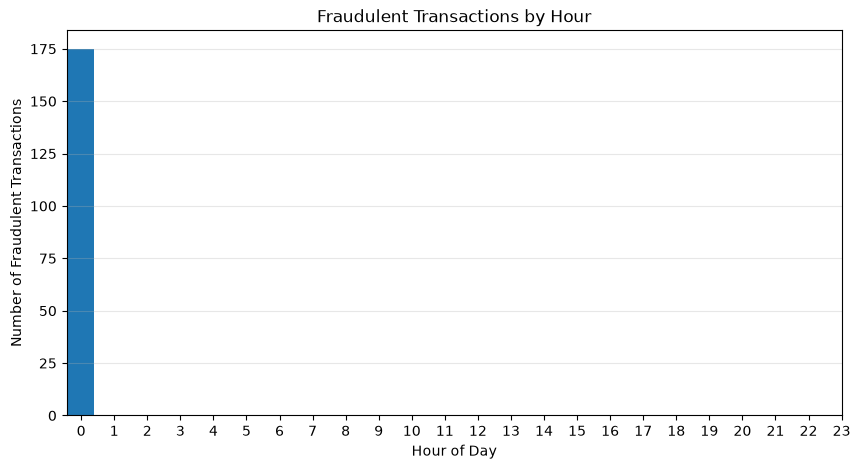

In [55]:
# ============================================================
# FRAUD TRANSACTIONS BY HOUR
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    hourly_analysis.index,
    hourly_analysis["fraud_transactions"]
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Fraudulent Transactions by Hour")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

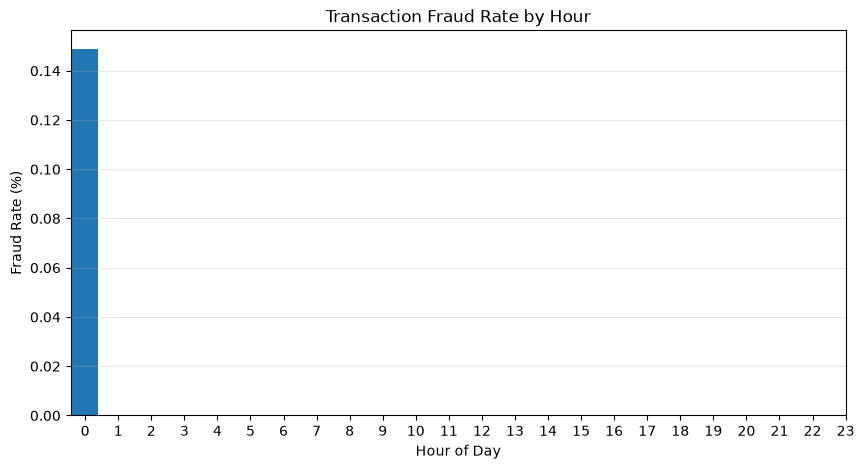

In [56]:
# ============================================================
# FRAUD RATE BY HOUR
# ============================================================
# Raw fraud count can be misleading if some hours have
# many more transactions.
# Therefore, we also visualize the fraud rate.
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    hourly_analysis.index,
    hourly_analysis["fraud_rate"]
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Transaction Fraud Rate by Hour")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

In [57]:
# ============================================================
# INSPECT ORIGINAL TIMESTAMP VALUES
# ============================================================
# We need to look at the raw values before deciding whether
# they represent seconds, milliseconds, microseconds, etc.
# ============================================================

print("Original TIMESTAMP values:")
print(transactions_df["TIMESTAMP"].head(20))

print("\nOriginal TIMESTAMP data type:")
print(transactions_df["TIMESTAMP"].dtype)

Original TIMESTAMP values:
0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
5    1970-01-01
6    1970-01-01
7    1970-01-01
8    1970-01-01
9    1970-01-01
10   1970-01-01
11   1970-01-01
12   1970-01-01
13   1970-01-01
14   1970-01-01
15   1970-01-01
16   1970-01-01
17   1970-01-01
18   1970-01-01
19   1970-01-01
Name: TIMESTAMP, dtype: datetime64[ns]

Original TIMESTAMP data type:
datetime64[ns]


In [58]:
# ============================================================
# RELOAD TRANSACTIONS TO RESTORE ORIGINAL TIMESTAMP VALUES
# ============================================================

transactions_df = pd.read_csv(transactions_path)

print("Original TIMESTAMP values:")
print(transactions_df["TIMESTAMP"].head(20))

print("\nOriginal TIMESTAMP data type:")
print(transactions_df["TIMESTAMP"].dtype)

Original TIMESTAMP values:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
Name: TIMESTAMP, dtype: int64

Original TIMESTAMP data type:
int64


In [59]:
# ============================================================
# RAW TIMESTAMP INVESTIGATION
# ============================================================
# Before converting TIMESTAMP into dates, we need to
# understand what the integer values actually represent.
# ============================================================

print("===== TIMESTAMP SUMMARY =====")

print("\nData type:")
print(transactions_df["TIMESTAMP"].dtype)

print("\nMinimum timestamp:")
print(transactions_df["TIMESTAMP"].min())

print("\nMaximum timestamp:")
print(transactions_df["TIMESTAMP"].max())

print("\nNumber of unique timestamp values:")
print(transactions_df["TIMESTAMP"].nunique())

print("\nFirst 20 unique timestamp values:")
print(
    transactions_df["TIMESTAMP"]
    .drop_duplicates()
    .sort_values()
    .head(20)
)

print("\nLast 20 unique timestamp values:")
print(
    transactions_df["TIMESTAMP"]
    .drop_duplicates()
    .sort_values()
    .tail(20)
)

===== TIMESTAMP SUMMARY =====

Data type:
int64

Minimum timestamp:
0

Maximum timestamp:
199

Number of unique timestamp values:
200

First 20 unique timestamp values:
0         0
306       1
757       2
1155      3
1742      4
2453      5
3048      6
3670      7
4320      8
4815      9
5371     10
5786     11
6373     12
6881     13
7572     14
8366     15
8932     16
9588     17
10241    18
10815    19
Name: TIMESTAMP, dtype: int64

Last 20 unique timestamp values:
105944    180
106364    181
106971    182
107505    183
108157    184
108899    185
109551    186
110220    187
110882    188
111375    189
111903    190
112373    191
112992    192
113491    193
114158    194
114859    195
115335    196
115931    197
116502    198
117009    199
Name: TIMESTAMP, dtype: int64


In [60]:
# ============================================================
# TRANSACTIONS PER TIME STEP
# ============================================================
# TIMESTAMP contains synthetic integer time steps from 0 to 199.
# We count how many transactions occurred at each time step.
# ============================================================

transactions_per_time = (
    transactions_df
    .groupby("TIMESTAMP")
    .size()
)

print("===== TRANSACTIONS PER TIME STEP =====")
print(transactions_per_time)

print("\nMinimum transactions in a time step:")
print(transactions_per_time.min())

print("\nMaximum transactions in a time step:")
print(transactions_per_time.max())

===== TRANSACTIONS PER TIME STEP =====
TIMESTAMP
0      306
1      451
2      398
3      587
4      711
      ... 
195    476
196    596
197    571
198    507
199    524
Length: 200, dtype: int64

Minimum transactions in a time step:
306

Maximum transactions in a time step:
822


In [61]:
# ============================================================
# FRAUD TRANSACTIONS PER TIME STEP
# ============================================================
# Count fraudulent transactions at each synthetic time step.
# ============================================================

fraud_per_time = (
    transactions_df[
        transactions_df["IS_FRAUD"] == True
    ]
    .groupby("TIMESTAMP")
    .size()
)

print("===== FRAUD TRANSACTIONS PER TIME STEP =====")
print(fraud_per_time)

print("\nTime steps containing fraud:")
print(fraud_per_time.shape[0])

print("\nMaximum fraud transactions in one time step:")
print(fraud_per_time.max())

===== FRAUD TRANSACTIONS PER TIME STEP =====
TIMESTAMP
4      1
6      1
8      1
14     1
16     1
      ..
191    1
193    1
195    1
196    1
197    1
Length: 111, dtype: int64

Time steps containing fraud:
111

Maximum fraud transactions in one time step:
4


In [62]:
# ============================================================
# FRAUD RATE BY TIME STEP
# ============================================================
# Raw fraud counts can be misleading.
# We therefore calculate the percentage of transactions
# that are fraudulent at each time step.
# ============================================================

temporal_analysis = pd.DataFrame({
    "total_transactions": transactions_per_time,
    "fraud_transactions": fraud_per_time
}).fillna(0)

temporal_analysis["legitimate_transactions"] = (
    temporal_analysis["total_transactions"]
    - temporal_analysis["fraud_transactions"]
)

temporal_analysis["fraud_rate"] = (
    temporal_analysis["fraud_transactions"]
    / temporal_analysis["total_transactions"]
    * 100
)

print("===== TEMPORAL FRAUD ANALYSIS =====")
print(temporal_analysis)

===== TEMPORAL FRAUD ANALYSIS =====
           total_transactions  fraud_transactions  legitimate_transactions  \
TIMESTAMP                                                                    
0                         306                 0.0                    306.0   
1                         451                 0.0                    451.0   
2                         398                 0.0                    398.0   
3                         587                 0.0                    587.0   
4                         711                 1.0                    710.0   
...                       ...                 ...                      ...   
195                       476                 1.0                    475.0   
196                       596                 1.0                    595.0   
197                       571                 1.0                    570.0   
198                       507                 0.0                    507.0   
199                       52

In [63]:
# ============================================================
# HIGHEST FRAUD-RATE TIME STEPS
# ============================================================
# Sort time steps by fraud rate to identify where fraud
# is most concentrated.
# ============================================================

highest_fraud_times = (
    temporal_analysis
    .sort_values(
        by="fraud_rate",
        ascending=False
    )
)

print("===== TOP TIME STEPS BY FRAUD RATE =====")
print(highest_fraud_times.head(20))

===== TOP TIME STEPS BY FRAUD RATE =====
           total_transactions  fraud_transactions  legitimate_transactions  \
TIMESTAMP                                                                    
20                        404                 3.0                    401.0   
26                        590                 4.0                    586.0   
75                        592                 4.0                    588.0   
60                        448                 3.0                    445.0   
167                       621                 4.0                    617.0   
28                        484                 3.0                    481.0   
133                       661                 4.0                    657.0   
169                       519                 3.0                    516.0   
62                        527                 3.0                    524.0   
78                        553                 3.0                    550.0   
99                     

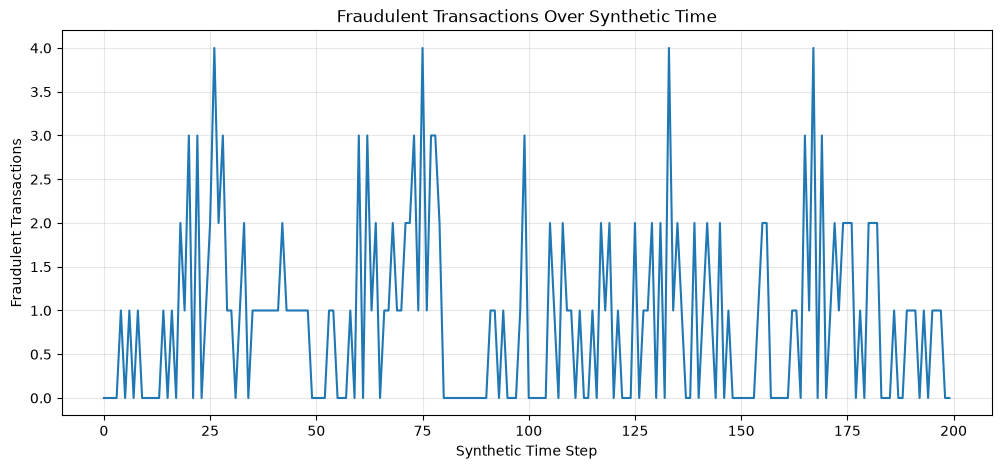

In [64]:
# ============================================================
# FRAUD TRANSACTIONS OVER SYNTHETIC TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    temporal_analysis.index,
    temporal_analysis["fraud_transactions"]
)

plt.xlabel("Synthetic Time Step")
plt.ylabel("Fraudulent Transactions")
plt.title("Fraudulent Transactions Over Synthetic Time")

plt.grid(alpha=0.3)

plt.show()

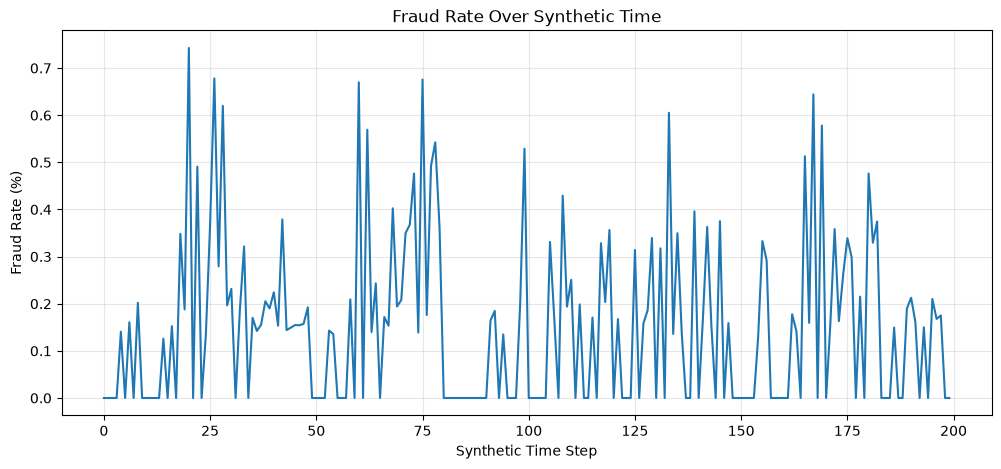

In [65]:
# ============================================================
# FRAUD RATE OVER SYNTHETIC TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    temporal_analysis.index,
    temporal_analysis["fraud_rate"]
)

plt.xlabel("Synthetic Time Step")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Synthetic Time")

plt.grid(alpha=0.3)

plt.show()

In [66]:
# ============================================================
# FRAUD PRESENCE BY TIME STEP
# ============================================================
# Create a simple indicator:
# 1 = at least one fraud transaction
# 0 = no fraud transaction
# ============================================================

temporal_analysis["fraud_present"] = (
    temporal_analysis["fraud_transactions"] > 0
).astype(int)

print("===== FRAUD PRESENCE =====")

print("\nTime steps with fraud:")
print(temporal_analysis["fraud_present"].sum())

print("\nTime steps without fraud:")
print(
    (temporal_analysis["fraud_present"] == 0).sum()
)

===== FRAUD PRESENCE =====

Time steps with fraud:
111

Time steps without fraud:
89


In [67]:
# ============================================================
# CONSECUTIVE FRAUD TIME STEPS
# ============================================================
# Shift the fraud indicator by one time step.
# This lets us check whether fraud occurred in the
# immediately previous time step.
# ============================================================

temporal_analysis["previous_time_fraud"] = (
    temporal_analysis["fraud_present"].shift(1)
)

temporal_analysis["consecutive_fraud"] = (
    (temporal_analysis["fraud_present"] == 1)
    &
    (temporal_analysis["previous_time_fraud"] == 1)
)

print("===== CONSECUTIVE FRAUD ANALYSIS =====")

print(
    "Number of time steps immediately following "
    "another fraud time step:"
)

print(
    temporal_analysis["consecutive_fraud"].sum()
)

===== CONSECUTIVE FRAUD ANALYSIS =====
Number of time steps immediately following another fraud time step:
68


In [68]:
# ============================================================
# GAPS BETWEEN FRAUD TIME STEPS
# ============================================================
# Identify the time steps where fraud occurred and calculate
# the number of time steps between consecutive fraud events.
# ============================================================

fraud_time_steps = (
    temporal_analysis[
        temporal_analysis["fraud_present"] == 1
    ]
    .index
    .to_numpy()
)

fraud_gaps = np.diff(fraud_time_steps)

print("===== FRAUD TIME-STEP GAPS =====")

print("\nMinimum gap:")
print(fraud_gaps.min())

print("\nMaximum gap:")
print(fraud_gaps.max())

print("\nAverage gap:")
print(fraud_gaps.mean())

print("\nFirst 30 gaps:")
print(fraud_gaps[:30])

===== FRAUD TIME-STEP GAPS =====

Minimum gap:
1

Maximum gap:
12

Average gap:
1.7545454545454546

First 30 gaps:
[2 2 6 2 2 1 1 2 2 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1]


In [70]:
# ============================================================
# FRAUD BY TIME BLOCK
# ============================================================
# Divide the 200 synthetic time steps into 10 blocks:
#
# 0-19
# 20-39
# 40-59
# ...
# 180-199
#
# This helps us see whether fraud is concentrated in certain
# periods of the dataset.
# ============================================================

transactions_df["time_block"] = (
    transactions_df["TIMESTAMP"] // 20
)

time_block_analysis = (
    transactions_df
    .groupby("time_block")
    .agg(
        total_transactions=("TX_ID", "count"),
        fraud_transactions=("IS_FRAUD", "sum")
    )
)

time_block_analysis["fraud_rate"] = (
    time_block_analysis["fraud_transactions"]
    / time_block_analysis["total_transactions"]
    * 100
)

print("===== FRAUD BY TIME BLOCK =====")
print(time_block_analysis)

===== FRAUD BY TIME BLOCK =====
            total_transactions  fraud_transactions  fraud_rate
time_block                                                    
0                        11347                   8    0.070503
1                        11668                  28    0.239973
2                        12000                  13    0.108333
3                        11830                  36    0.304311
4                        12025                   7    0.058212
5                        11588                  14    0.120815
6                        11870                  19    0.160067
7                        11845                  12    0.101309
8                        11771                  24    0.203891
9                        11589                  14    0.120804


In [71]:
# ============================================================
# GAPS BETWEEN FRAUD TIME STEPS
# ============================================================
# Identify the time steps where fraud occurred and calculate
# the number of time steps between consecutive fraud events.
# ============================================================

fraud_time_steps = (
    temporal_analysis[
        temporal_analysis["fraud_present"] == 1
    ]
    .index
    .to_numpy()
)

fraud_gaps = np.diff(fraud_time_steps)

print("===== FRAUD TIME-STEP GAPS =====")

print("\nMinimum gap:")
print(fraud_gaps.min())

print("\nMaximum gap:")
print(fraud_gaps.max())

print("\nAverage gap:")
print(fraud_gaps.mean())

print("\nFirst 30 gaps:")
print(fraud_gaps[:30])

===== FRAUD TIME-STEP GAPS =====

Minimum gap:
1

Maximum gap:
12

Average gap:
1.7545454545454546

First 30 gaps:
[2 2 6 2 2 1 1 2 2 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1]


In [72]:
# ============================================================
# FRAUD BY TIME BLOCK
# ============================================================
# Divide the 200 synthetic time steps into 10 blocks:
#
# 0-19
# 20-39
# 40-59
# ...
# 180-199
#
# This helps us see whether fraud is concentrated in certain
# periods of the dataset.
# ============================================================

transactions_df["time_block"] = (
    transactions_df["TIMESTAMP"] // 20
)

time_block_analysis = (
    transactions_df
    .groupby("time_block")
    .agg(
        total_transactions=("TX_ID", "count"),
        fraud_transactions=("IS_FRAUD", "sum")
    )
)

time_block_analysis["fraud_rate"] = (
    time_block_analysis["fraud_transactions"]
    / time_block_analysis["total_transactions"]
    * 100
)

print("===== FRAUD BY TIME BLOCK =====")
print(time_block_analysis)

===== FRAUD BY TIME BLOCK =====
            total_transactions  fraud_transactions  fraud_rate
time_block                                                    
0                        11347                   8    0.070503
1                        11668                  28    0.239973
2                        12000                  13    0.108333
3                        11830                  36    0.304311
4                        12025                   7    0.058212
5                        11588                  14    0.120815
6                        11870                  19    0.160067
7                        11845                  12    0.101309
8                        11771                  24    0.203891
9                        11589                  14    0.120804


In [73]:
# ============================================================
# HIGHEST FRAUD TIME BLOCKS
# ============================================================

print("===== TIME BLOCKS SORTED BY FRAUD RATE =====")

print(
    time_block_analysis
    .sort_values(
        "fraud_rate",
        ascending=False
    )
)

===== TIME BLOCKS SORTED BY FRAUD RATE =====
            total_transactions  fraud_transactions  fraud_rate
time_block                                                    
3                        11830                  36    0.304311
1                        11668                  28    0.239973
8                        11771                  24    0.203891
6                        11870                  19    0.160067
5                        11588                  14    0.120815
9                        11589                  14    0.120804
2                        12000                  13    0.108333
7                        11845                  12    0.101309
0                        11347                   8    0.070503
4                        12025                   7    0.058212


In [74]:
# ============================================================
# ALERT TYPE DISTRIBUTION
# ============================================================
# First, we check what types of alerts exist in the dataset.
# ============================================================

print("===== ALERT TYPE DISTRIBUTION =====")

print(
    alerts_df["ALERT_TYPE"]
    .value_counts()
)

print("\n===== ALERT TYPE DISTRIBUTION (%) =====")

print(
    alerts_df["ALERT_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
)

===== ALERT TYPE DISTRIBUTION =====
ALERT_TYPE
cycle     96
fan_in    79
Name: count, dtype: int64

===== ALERT TYPE DISTRIBUTION (%) =====
ALERT_TYPE
cycle     54.857143
fan_in    45.142857
Name: proportion, dtype: float64


In [75]:
# ============================================================
# ALERT FRAUD STATUS
# ============================================================
# Check whether alerts contain fraudulent and/or legitimate
# transactions.
# ============================================================

print("===== ALERT FRAUD STATUS =====")

print(
    alerts_df["IS_FRAUD"]
    .value_counts()
)

print("\n===== ALERT FRAUD STATUS (%) =====")

print(
    alerts_df["IS_FRAUD"]
    .value_counts(normalize=True)
    .mul(100)
)

===== ALERT FRAUD STATUS =====
IS_FRAUD
True    175
Name: count, dtype: int64

===== ALERT FRAUD STATUS (%) =====
IS_FRAUD
True    100.0
Name: proportion, dtype: float64


In [76]:
# ============================================================
# TRANSACTIONS PER ALERT ID
# ============================================================
# ALERT_ID identifies an alert/group rather than a unique row.
# We count how many transactions are associated with each alert.
# ============================================================

transactions_per_alert = (
    alerts_df
    .groupby("ALERT_ID")
    .size()
    .sort_values(ascending=False)
)

print("===== TRANSACTIONS PER ALERT ID =====")

print(transactions_per_alert)

print("\nNumber of unique ALERT_IDs:")
print(transactions_per_alert.shape[0])

print("\nMinimum transactions per alert:")
print(transactions_per_alert.min())

print("\nMaximum transactions per alert:")
print(transactions_per_alert.max())

===== TRANSACTIONS PER ALERT ID =====
ALERT_ID
20    5
21    5
23    5
24    5
25    5
27    5
28    5
29    5
30    5
31    5
32    5
33    5
34    5
35    5
36    5
37    5
38    5
22    5
39    5
19    4
10    4
2     4
3     4
4     4
5     4
6     4
7     4
8     4
9     4
11    4
1     4
12    4
13    4
15    4
16    4
17    4
18    4
0     4
14    3
26    1
dtype: int64

Number of unique ALERT_IDs:
40

Minimum transactions per alert:
1

Maximum transactions per alert:
5


In [77]:
# ============================================================
# ALERT TYPE VS TRANSACTION AMOUNT
# ============================================================
# Compare transaction amounts associated with different
# alert types.
# ============================================================

alert_type_amount = (
    alerts_df
    .groupby("ALERT_TYPE")
    .agg(
        alert_count=("ALERT_ID", "count"),
        average_amount=("TX_AMOUNT", "mean"),
        minimum_amount=("TX_AMOUNT", "min"),
        maximum_amount=("TX_AMOUNT", "max")
    )
    .sort_values(
        "alert_count",
        ascending=False
    )
)

print("===== ALERT TYPE / AMOUNT ANALYSIS =====")
print(alert_type_amount)

===== ALERT TYPE / AMOUNT ANALYSIS =====
            alert_count  average_amount  minimum_amount  maximum_amount
ALERT_TYPE                                                             
cycle                96       14.890833           10.39           19.96
fan_in               79        3.785570            2.57            4.90


In [78]:
# ============================================================
# ALERT ↔ TRANSACTION MATCHING
# ============================================================
# Every alert contains a TX_ID.
# We verify whether those transaction IDs actually exist
# in the main transaction dataset.
# ============================================================

alert_tx_ids = set(alerts_df["TX_ID"])

transaction_tx_ids = set(transactions_df["TX_ID"])

matching_tx_ids = (
    alert_tx_ids.intersection(transaction_tx_ids)
)

missing_tx_ids = (
    alert_tx_ids - transaction_tx_ids
)

print("===== ALERT / TRANSACTION MATCH =====")

print("Unique TX_IDs in alerts:")
print(len(alert_tx_ids))

print("\nMatching TX_IDs in transactions:")
print(len(matching_tx_ids))

print("\nAlert TX_IDs missing from transactions:")
print(len(missing_tx_ids))

===== ALERT / TRANSACTION MATCH =====
Unique TX_IDs in alerts:
175

Matching TX_IDs in transactions:
175

Alert TX_IDs missing from transactions:
0


In [79]:
# ============================================================
# ALERT FRAUD LABEL VS TRANSACTION FRAUD LABEL
# ============================================================
# Merge the alert information with the original transaction
# fraud label and compare both labels.
# ============================================================

alert_transaction_check = alerts_df[
    ["TX_ID", "IS_FRAUD"]
].merge(
    transactions_df[
        ["TX_ID", "IS_FRAUD"]
    ],
    on="TX_ID",
    suffixes=(
        "_alert",
        "_transaction"
    )
)

alert_transaction_check["label_match"] = (
    alert_transaction_check["IS_FRAUD_alert"]
    ==
    alert_transaction_check["IS_FRAUD_transaction"]
)

print("===== ALERT / TRANSACTION FRAUD LABEL CHECK =====")

print(
    alert_transaction_check["label_match"]
    .value_counts()
)

print("\nNumber of mismatched labels:")
print(
    (~alert_transaction_check["label_match"]).sum()
)

===== ALERT / TRANSACTION FRAUD LABEL CHECK =====
label_match
True    175
Name: count, dtype: int64

Number of mismatched labels:
0


In [80]:
# ============================================================
# ALERT INFORMATION OVERVIEW
# ============================================================
# These columns describe the transaction associated with
# an alert. We list them so we can later decide which
# features would cause target leakage.
# ============================================================

print("===== ALERT DATASET COLUMNS =====")

for column in alerts_df.columns:
    print("-", column)

print("\nNumber of alert rows:")
print(len(alerts_df))

print("\nNumber of unique transactions represented:")
print(alerts_df["TX_ID"].nunique())

===== ALERT DATASET COLUMNS =====
- ALERT_ID
- ALERT_TYPE
- IS_FRAUD
- TX_ID
- SENDER_ACCOUNT_ID
- RECEIVER_ACCOUNT_ID
- TX_TYPE
- TX_AMOUNT
- TIMESTAMP

Number of alert rows:
175

Number of unique transactions represented:
175


In [81]:
# ============================================================
# SECTION 9.1 — CUSTOMER TO ACCOUNT RELATIONSHIP
# ============================================================

customer_account_summary = (
    accounts_df
    .groupby("CUSTOMER_ID")
    .agg(
        account_count=("ACCOUNT_ID", "count"),
        fraud_accounts=("IS_FRAUD", "sum")
    )
    .sort_values("account_count", ascending=False)
)

print("===== CUSTOMER → ACCOUNT SUMMARY =====")
print(customer_account_summary.head(20))

print("\n===== OVERALL CUSTOMER STATISTICS =====")
print("Total unique customers:", accounts_df["CUSTOMER_ID"].nunique())
print("Total accounts:", len(accounts_df))
print("Maximum accounts owned by one customer:",
      customer_account_summary["account_count"].max())

===== CUSTOMER → ACCOUNT SUMMARY =====
             account_count  fraud_accounts
CUSTOMER_ID                               
C_0                      1               0
C_702                    1               1
C_691                    1               1
C_692                    1               1
C_693                    1               0
C_694                    1               0
C_695                    1               0
C_696                    1               0
C_697                    1               0
C_698                    1               0
C_699                    1               0
C_7                      1               0
C_70                     1               1
C_700                    1               0
C_701                    1               0
C_703                    1               0
C_717                    1               1
C_704                    1               0
C_705                    1               0
C_706                    1               0

===== OVERALL 

In [82]:
# ============================================================
# SECTION 9.2 — ACCOUNT COUNT DISTRIBUTION PER CUSTOMER
# ============================================================

accounts_per_customer = (
    accounts_df
    .groupby("CUSTOMER_ID")["ACCOUNT_ID"]
    .count()
)

print("===== ACCOUNTS PER CUSTOMER =====")
print(accounts_per_customer.value_counts().sort_index())

print("\nAverage accounts per customer:",
      accounts_per_customer.mean())

print("Customers with more than one account:",
      (accounts_per_customer > 1).sum())

print("Customers with exactly one account:",
      (accounts_per_customer == 1).sum())

===== ACCOUNTS PER CUSTOMER =====
ACCOUNT_ID
1    1000
Name: count, dtype: int64

Average accounts per customer: 1.0
Customers with more than one account: 0
Customers with exactly one account: 1000


In [83]:
# ============================================================
# SECTION 9.3 — CUSTOMER-LEVEL FRAUD ANALYSIS
# ============================================================

customer_fraud_summary = (
    accounts_df
    .groupby("CUSTOMER_ID")
    .agg(
        total_accounts=("ACCOUNT_ID", "count"),
        fraud_accounts=("IS_FRAUD", "sum")
    )
)

customer_fraud_summary["has_fraud_account"] = (
    customer_fraud_summary["fraud_accounts"] > 0
)

print("===== CUSTOMER FRAUD SUMMARY =====")
print(customer_fraud_summary.head(20))

print("\n===== CUSTOMER FRAUD STATISTICS =====")
print(
    "Customers with at least one fraud-labelled account:",
    customer_fraud_summary["has_fraud_account"].sum()
)

print(
    "Customers with no fraud-labelled accounts:",
    (~customer_fraud_summary["has_fraud_account"]).sum()
)

===== CUSTOMER FRAUD SUMMARY =====
             total_accounts  fraud_accounts  has_fraud_account
CUSTOMER_ID                                                   
C_0                       1               0              False
C_1                       1               0              False
C_10                      1               0              False
C_100                     1               0              False
C_101                     1               0              False
C_102                     1               0              False
C_103                     1               0              False
C_104                     1               0              False
C_105                     1               0              False
C_106                     1               0              False
C_107                     1               0              False
C_108                     1               0              False
C_109                     1               0              False
C_11                

In [84]:
# ============================================================
# SECTION 9.4 — ACCOUNT SENDER / RECEIVER ACTIVITY
# ============================================================

# Count how many transactions each account sends
sent_counts = (
    transactions_df["SENDER_ACCOUNT_ID"]
    .value_counts()
    .rename("sent_transaction_count")
)

# Count how many transactions each account receives
received_counts = (
    transactions_df["RECEIVER_ACCOUNT_ID"]
    .value_counts()
    .rename("received_transaction_count")
)

# Total amount sent by each account
sent_amounts = (
    transactions_df
    .groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"]
    .sum()
    .rename("total_sent_amount")
)

# Total amount received by each account
received_amounts = (
    transactions_df
    .groupby("RECEIVER_ACCOUNT_ID")["TX_AMOUNT"]
    .sum()
    .rename("total_received_amount")
)

# Combine all activity information
account_activity = (
    accounts_df[["ACCOUNT_ID", "CUSTOMER_ID", "IS_FRAUD", "TX_BEHAVIOR_ID"]]
    .set_index("ACCOUNT_ID")
    .join(sent_counts)
    .join(received_counts)
    .join(sent_amounts)
    .join(received_amounts)
    .fillna(0)
)

print("===== ACCOUNT ACTIVITY =====")
print(account_activity.head(20))

===== ACCOUNT ACTIVITY =====
           CUSTOMER_ID  IS_FRAUD  TX_BEHAVIOR_ID  sent_transaction_count  \
ACCOUNT_ID                                                                 
0                  C_0     False               1                      19   
1                  C_1     False               1                      19   
2                  C_2     False               1                      21   
3                  C_3     False               1                      23   
4                  C_4     False               1                      40   
5                  C_5     False               1                      40   
6                  C_6     False               1                      44   
7                  C_7     False               1                      42   
8                  C_8     False               1                      42   
9                  C_9     False               1                      44   
10                C_10     False               1           

In [85]:
# ============================================================
# SECTION 9.5 — MOST ACTIVE ACCOUNTS
# ============================================================

print("===== TOP 10 SENDER ACCOUNTS =====")

print(
    account_activity
    .sort_values("sent_transaction_count", ascending=False)
    [["CUSTOMER_ID", "sent_transaction_count", "total_sent_amount"]]
    .head(10)
)

print("\n===== TOP 10 RECEIVER ACCOUNTS =====")

print(
    account_activity
    .sort_values("received_transaction_count", ascending=False)
    [["CUSTOMER_ID", "received_transaction_count", "total_received_amount"]]
    .head(10)
)

===== TOP 10 SENDER ACCOUNTS =====
           CUSTOMER_ID  sent_transaction_count  total_sent_amount
ACCOUNT_ID                                                       
978              C_978                     761          102861.86
979              C_979                     740          141806.20
976              C_976                     720          123840.00
977              C_977                     701          117695.70
974              C_974                     701          134720.03
972              C_972                     682           90407.72
971              C_971                     681          106507.96
975              C_975                     680          107854.80
970              C_970                     660           79794.00
973              C_973                     660          129921.00

===== TOP 10 RECEIVER ACCOUNTS =====
           CUSTOMER_ID  received_transaction_count  total_received_amount
ACCOUNT_ID                                                   

In [87]:
# ============================================================
# SECTION 9.6 — FRAUDULENT SENDER / RECEIVER RELATIONSHIPS
# ============================================================

fraud_transactions = transactions_df[
    transactions_df["IS_FRAUD"] == True
]

unique_fraud_senders = fraud_transactions[
    "SENDER_ACCOUNT_ID"
].nunique()

unique_fraud_receivers = fraud_transactions[
    "RECEIVER_ACCOUNT_ID"
].nunique()

print("===== FRAUD ACCOUNT RELATIONSHIPS =====")

print("Fraudulent transactions:", len(fraud_transactions))
print("Unique fraudulent senders:", unique_fraud_senders)
print("Unique fraudulent receivers:", unique_fraud_receivers)

print(
    "Fraudulent sender-receiver pairs:",
    fraud_transactions[
        ["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID"]
    ].drop_duplicates().shape[0]
)

print("\nTop receivers involved in fraudulent transactions:")

print(
    fraud_transactions["RECEIVER_ACCOUNT_ID"]
    .value_counts()
    .head(10)
)

print("\nTop senders involved in fraudulent transactions:")

print(
    fraud_transactions["SENDER_ACCOUNT_ID"]
    .value_counts()
    .head(10)
)

===== FRAUD ACCOUNT RELATIONSHIPS =====
Fraudulent transactions: 175
Unique fraudulent senders: 146
Unique fraudulent receivers: 100
Fraudulent sender-receiver pairs: 175

Top receivers involved in fraudulent transactions:
RECEIVER_ACCOUNT_ID
997    7
996    6
752    5
578    5
998    5
926    5
889    4
350    4
730    4
842    4
Name: count, dtype: int64

Top senders involved in fraudulent transactions:
SENDER_ACCOUNT_ID
996    4
999    4
956    3
919    3
997    3
488    2
811    2
753    2
424    2
819    2
Name: count, dtype: int64


In [88]:
# ============================================================
# SECTION 9.7 — ACCOUNT FRAUD LABEL VS TRANSACTION INVOLVEMENT
# ============================================================

fraud_sender_accounts = set(
    fraud_transactions["SENDER_ACCOUNT_ID"]
)

fraud_receiver_accounts = set(
    fraud_transactions["RECEIVER_ACCOUNT_ID"]
)

account_activity["fraud_as_sender"] = (
    account_activity.index.isin(fraud_sender_accounts)
)

account_activity["fraud_as_receiver"] = (
    account_activity.index.isin(fraud_receiver_accounts)
)

account_activity["fraud_transaction_involvement"] = (
    account_activity["fraud_as_sender"]
    | account_activity["fraud_as_receiver"]
)

print("===== FRAUD ACCOUNT COMPARISON =====")

print(
    "Accounts labelled IS_FRAUD = True:",
    account_activity["IS_FRAUD"].sum()
)

print(
    "Accounts involved in fraudulent transactions:",
    account_activity["fraud_transaction_involvement"].sum()
)

print(
    "Fraud-labelled accounts also involved in fraud transactions:",
    (
        account_activity["IS_FRAUD"]
        & account_activity["fraud_transaction_involvement"]
    ).sum()
)

print(
    "Fraud-labelled accounts NOT involved in fraud transactions:",
    (
        account_activity["IS_FRAUD"]
        & ~account_activity["fraud_transaction_involvement"]
    ).sum()
)

===== FRAUD ACCOUNT COMPARISON =====
Accounts labelled IS_FRAUD = True: 162
Accounts involved in fraudulent transactions: 159
Fraud-labelled accounts also involved in fraud transactions: 159
Fraud-labelled accounts NOT involved in fraud transactions: 3


In [89]:
# ============================================================
# SECTION 10.1 — UNIQUE RECEIVERS PER SENDER
# ============================================================

sender_network = (
    transactions_df
    .groupby("SENDER_ACCOUNT_ID")
    .agg(
        total_transactions=("TX_ID", "count"),
        unique_receivers=("RECEIVER_ACCOUNT_ID", "nunique"),
        total_sent_amount=("TX_AMOUNT", "sum"),
        average_sent_amount=("TX_AMOUNT", "mean")
    )
    .sort_values("unique_receivers", ascending=False)
)

print("===== SENDER NETWORK ACTIVITY =====")
print(sender_network.head(20))

print("\n===== NETWORK STATISTICS =====")
print("Total senders:", len(sender_network))
print(
    "Maximum unique receivers for one sender:",
    sender_network["unique_receivers"].max()
)

===== SENDER NETWORK ACTIVITY =====
                   total_transactions  unique_receivers  total_sent_amount  \
SENDER_ACCOUNT_ID                                                            
978                               761                39          102861.86   
979                               740                37          141806.20   
976                               720                36          123840.00   
974                               701                36          134720.03   
971                               681                35          106507.96   
977                               701                35          117695.70   
972                               682                34           90407.72   
975                               680                34          107854.80   
970                               660                33           79794.00   
973                               660                33          129921.00   
968                         

In [90]:
# ============================================================
# SECTION 10.2 — UNIQUE SENDERS PER RECEIVER
# ============================================================

receiver_network = (
    transactions_df
    .groupby("RECEIVER_ACCOUNT_ID")
    .agg(
        total_transactions=("TX_ID", "count"),
        unique_senders=("SENDER_ACCOUNT_ID", "nunique"),
        total_received_amount=("TX_AMOUNT", "sum"),
        average_received_amount=("TX_AMOUNT", "mean")
    )
    .sort_values("unique_senders", ascending=False)
)

print("===== RECEIVER NETWORK ACTIVITY =====")
print(receiver_network.head(20))

print("\n===== NETWORK STATISTICS =====")
print("Total receivers:", len(receiver_network))
print(
    "Maximum unique senders for one receiver:",
    receiver_network["unique_senders"].max()
)

===== RECEIVER NETWORK ACTIVITY =====
                     total_transactions  unique_senders  \
RECEIVER_ACCOUNT_ID                                       
999                                 945              63   
998                                 824              57   
997                                 685              53   
990                                1582              44   
994                                 804              40   
992                                1286              38   
996                                 529              38   
991                                1674              36   
993                                1052              36   
995                                 457              32   
985                                 611              32   
988                                 429              29   
986                                 406              28   
984                                 502              27   
989               

In [91]:
# ============================================================
# SECTION 10.3 — FAN-IN ANALYSIS
# ============================================================

fan_in_analysis = (
    transactions_df
    .groupby("RECEIVER_ACCOUNT_ID")
    .agg(
        unique_senders=("SENDER_ACCOUNT_ID", "nunique"),
        total_transactions=("TX_ID", "count"),
        total_amount=("TX_AMOUNT", "sum"),
        average_amount=("TX_AMOUNT", "mean")
    )
    .sort_values("unique_senders", ascending=False)
)

print("===== TOP FAN-IN RECEIVERS =====")
print(fan_in_analysis.head(20))

print("\n===== FAN-IN THRESHOLDS =====")

for threshold in [5, 10, 20, 50, 100]:
    count = (
        fan_in_analysis["unique_senders"] >= threshold
    ).sum()

    print(
        f"Receivers with at least {threshold} unique senders:",
        count
    )

===== TOP FAN-IN RECEIVERS =====
                     unique_senders  total_transactions  total_amount  \
RECEIVER_ACCOUNT_ID                                                     
999                              63                 945   32972969.97   
998                              57                 824   25214273.38   
997                              53                 685   21531975.41   
990                              44                1582   11127524.79   
994                              40                 804    9507721.49   
992                              38                1286   25537120.76   
996                              38                 529   26247414.83   
991                              36                1674   12114031.09   
993                              36                1052   34812675.81   
995                              32                 457   10388729.65   
985                              32                 611   22559396.22   
988               

In [92]:
# ============================================================
# SECTION 10.4 — FRAUDULENT FAN-IN ANALYSIS
# ============================================================

fraud_fan_in = (
    fraud_transactions
    .groupby("RECEIVER_ACCOUNT_ID")
    .agg(
        unique_fraud_senders=("SENDER_ACCOUNT_ID", "nunique"),
        fraud_transactions=("TX_ID", "count"),
        total_fraud_amount=("TX_AMOUNT", "sum"),
        average_fraud_amount=("TX_AMOUNT", "mean")
    )
    .sort_values("unique_fraud_senders", ascending=False)
)

print("===== FRAUDULENT FAN-IN =====")
print(fraud_fan_in.head(20))

print("\nMaximum unique fraudulent senders for one receiver:",
      fraud_fan_in["unique_fraud_senders"].max())

===== FRAUDULENT FAN-IN =====
                     unique_fraud_senders  fraud_transactions  \
RECEIVER_ACCOUNT_ID                                             
997                                     7                   7   
996                                     6                   6   
752                                     5                   5   
998                                     5                   5   
578                                     5                   5   
926                                     5                   5   
328                                     4                   4   
730                                     4                   4   
725                                     4                   4   
842                                     4                   4   
664                                     4                   4   
877                                     4                   4   
889                                     4                   

In [93]:
# ============================================================
# SECTION 10.5 — DIRECT TWO-ACCOUNT CYCLES
# ============================================================

# Create directed sender → receiver pairs
transaction_pairs = set(
    zip(
        transactions_df["SENDER_ACCOUNT_ID"],
        transactions_df["RECEIVER_ACCOUNT_ID"]
    )
)

# Find pairs where the reverse direction also exists
cycles = set()

for sender, receiver in transaction_pairs:

    # Avoid self-transactions
    if sender == receiver:
        continue

    if (receiver, sender) in transaction_pairs:

        # Store pair in sorted order so A→B and B→A
        # are counted as one cycle
        cycle_pair = tuple(sorted((sender, receiver)))

        cycles.add(cycle_pair)

print("===== DIRECT TWO-ACCOUNT CYCLES =====")
print("Number of unique account pairs forming a cycle:",
      len(cycles))

print("\nSample cycles:")
print(list(cycles)[:20])

===== DIRECT TWO-ACCOUNT CYCLES =====
Number of unique account pairs forming a cycle: 155

Sample cycles:
[(540, 660), (441, 776), (257, 320), (69, 950), (784, 923), (828, 935), (40, 212), (259, 720), (264, 743), (349, 366), (25, 843), (148, 861), (152, 474), (432, 757), (832, 965), (756, 909), (66, 944), (251, 819), (125, 258), (451, 782)]


In [94]:
# ============================================================
# SECTION 10.6 — FRAUDULENT TRANSACTIONS IN CYCLES
# ============================================================

fraud_cycle_transactions = []

for _, row in fraud_transactions.iterrows():

    sender = row["SENDER_ACCOUNT_ID"]
    receiver = row["RECEIVER_ACCOUNT_ID"]

    if sender == receiver:
        continue

    pair = tuple(sorted((sender, receiver)))

    if pair in cycles:
        fraud_cycle_transactions.append(row)

fraud_cycle_df = pd.DataFrame(fraud_cycle_transactions)

print("===== FRAUD TRANSACTIONS INVOLVING CYCLE PAIRS =====")
print("Fraud transactions in cycle pairs:",
      len(fraud_cycle_df))

if len(fraud_cycle_df) > 0:
    print("\nExamples:")
    print(
        fraud_cycle_df[
            [
                "TX_ID",
                "SENDER_ACCOUNT_ID",
                "RECEIVER_ACCOUNT_ID",
                "TX_AMOUNT",
                "TIMESTAMP"
            ]
        ].head(20)
    )
else:
    print("No fraudulent transactions were found in direct cycle pairs.")

===== FRAUD TRANSACTIONS INVOLVING CYCLE PAIRS =====
Fraud transactions in cycle pairs: 24

Examples:
       TX_ID  SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID  TX_AMOUNT  TIMESTAMP
10915  10916                201                  753      10.39         19
11394  11395                918                  889       3.94         20
12886  12887                753                  350       3.53         22
12943  12944                783                  971      19.96         22
15035  15036                752                  201      10.39         26
31184  31185                961                  570      19.13         53
40427  40428                883                  932      12.00         68
43390  43391                909                  752       3.47         74
58490  58491                997                  260      15.81         99
62241  62242                617                  220      13.14        105
63862  63863                258                  125      12.36        10

In [95]:
# ============================================================
# SECTION 10.7 — FRAUD VS OVERALL NETWORK CONNECTIVITY
# ============================================================

# Sender connectivity
fraud_sender_network = (
    fraud_transactions
    .groupby("SENDER_ACCOUNT_ID")
    .agg(
        fraud_transactions=("TX_ID", "count"),
        unique_fraud_receivers=("RECEIVER_ACCOUNT_ID", "nunique")
    )
)

# Receiver connectivity
fraud_receiver_network = (
    fraud_transactions
    .groupby("RECEIVER_ACCOUNT_ID")
    .agg(
        fraud_transactions=("TX_ID", "count"),
        unique_fraud_senders=("SENDER_ACCOUNT_ID", "nunique")
    )
)

print("===== FRAUD SENDER CONNECTIVITY =====")
print(fraud_sender_network.sort_values(
    "unique_fraud_receivers",
    ascending=False
).head(15))

print("\n===== FRAUD RECEIVER CONNECTIVITY =====")
print(fraud_receiver_network.sort_values(
    "unique_fraud_senders",
    ascending=False
).head(15))


===== FRAUD SENDER CONNECTIVITY =====
                   fraud_transactions  unique_fraud_receivers
SENDER_ACCOUNT_ID                                            
999                                 4                       4
996                                 4                       4
997                                 3                       3
919                                 3                       3
956                                 3                       3
644                                 2                       2
905                                 2                       2
915                                 2                       2
488                                 2                       2
931                                 2                       2
819                                 2                       2
811                                 2                       2
961                                 2                       2
784                             

In [96]:
# ============================================================
# SECTION 11.1 — CROSS-DATASET FRAUD LABEL VALIDATION
# ============================================================

# Fraud transaction IDs from transactions.csv
transaction_fraud_ids = set(
    transactions_df.loc[
        transactions_df["IS_FRAUD"] == True,
        "TX_ID"
    ]
)

# Transaction IDs present in alerts.csv
alert_transaction_ids = set(
    alerts_df["TX_ID"]
)

# Fraud transaction IDs from alerts.csv
alert_fraud_ids = set(
    alerts_df.loc[
        alerts_df["IS_FRAUD"] == True,
        "TX_ID"
    ]
)

print("===== CROSS-DATASET FRAUD VALIDATION =====")

print("Fraud TX IDs in transactions:",
      len(transaction_fraud_ids))

print("TX IDs in alerts:",
      len(alert_transaction_ids))

print("Fraud TX IDs in alerts:",
      len(alert_fraud_ids))

print(
    "Fraud transactions missing from alerts:",
    len(transaction_fraud_ids - alert_transaction_ids)
)

print(
    "Alert transactions missing from transactions:",
    len(alert_transaction_ids - set(transactions_df["TX_ID"]))
)

print(
    "Fraud label mismatch between datasets:",
    len(transaction_fraud_ids.symmetric_difference(alert_fraud_ids))
)

===== CROSS-DATASET FRAUD VALIDATION =====
Fraud TX IDs in transactions: 175
TX IDs in alerts: 175
Fraud TX IDs in alerts: 175
Fraud transactions missing from alerts: 0
Alert transactions missing from transactions: 0
Fraud label mismatch between datasets: 0


In [97]:
# ============================================================
# SECTION 11.2 — ID RELATIONSHIP VALIDATION
# ============================================================

account_ids = set(accounts_df["ACCOUNT_ID"])
transaction_sender_ids = set(transactions_df["SENDER_ACCOUNT_ID"])
transaction_receiver_ids = set(transactions_df["RECEIVER_ACCOUNT_ID"])

print("===== ACCOUNT ID VALIDATION =====")

print(
    "Sender accounts missing from accounts.csv:",
    len(transaction_sender_ids - account_ids)
)

print(
    "Receiver accounts missing from accounts.csv:",
    len(transaction_receiver_ids - account_ids)
)

print(
    "Accounts never used as sender:",
    len(account_ids - transaction_sender_ids)
)

print(
    "Accounts never used as receiver:",
    len(account_ids - transaction_receiver_ids)
)

===== ACCOUNT ID VALIDATION =====
Sender accounts missing from accounts.csv: 0
Receiver accounts missing from accounts.csv: 0
Accounts never used as sender: 0
Accounts never used as receiver: 14


In [98]:
# ============================================================
# SECTION 11.3 — CONSTANT COLUMN CHECK
# ============================================================

print("===== CONSTANT COLUMNS =====")

print("\nAccounts:")

for column in accounts_df.columns:
    print(
        f"{column}: {accounts_df[column].nunique()} unique values"
    )

print("\nTransactions:")

for column in transactions_df.columns:
    print(
        f"{column}: {transactions_df[column].nunique()} unique values"
    )

print("\nAlerts:")

for column in alerts_df.columns:
    print(
        f"{column}: {alerts_df[column].nunique()} unique values"
    )

===== CONSTANT COLUMNS =====

Accounts:
ACCOUNT_ID: 1000 unique values
CUSTOMER_ID: 1000 unique values
INIT_BALANCE: 986 unique values
COUNTRY: 1 unique values
ACCOUNT_TYPE: 1 unique values
IS_FRAUD: 2 unique values
TX_BEHAVIOR_ID: 5 unique values

Transactions:
TX_ID: 117533 unique values
SENDER_ACCOUNT_ID: 1000 unique values
RECEIVER_ACCOUNT_ID: 986 unique values
TX_TYPE: 1 unique values
TX_AMOUNT: 4831 unique values
TIMESTAMP: 200 unique values
IS_FRAUD: 2 unique values
ALERT_ID: 41 unique values
time_block: 10 unique values

Alerts:
ALERT_ID: 40 unique values
ALERT_TYPE: 2 unique values
IS_FRAUD: 1 unique values
TX_ID: 175 unique values
SENDER_ACCOUNT_ID: 146 unique values
RECEIVER_ACCOUNT_ID: 100 unique values
TX_TYPE: 1 unique values
TX_AMOUNT: 84 unique values
TIMESTAMP: 111 unique values


In [99]:
# ============================================================
# SECTION 11.4 — IDENTIFIER UNIQUENESS CHECK
# ============================================================

print("===== IDENTIFIER UNIQUENESS =====")

identifier_columns = {
    "Accounts": ["ACCOUNT_ID", "CUSTOMER_ID"],
    "Transactions": ["TX_ID"],
    "Alerts": ["ALERT_ID", "TX_ID"]
}

for dataset_name, columns in identifier_columns.items():

    print(f"\n{dataset_name}:")

    if dataset_name == "Accounts":
        df = accounts_df
    elif dataset_name == "Transactions":
        df = transactions_df
    else:
        df = alerts_df

    for column in columns:

        unique_count = df[column].nunique()
        total_count = len(df)

        print(
            f"{column}: "
            f"{unique_count} unique / {total_count} rows"
        )
        

===== IDENTIFIER UNIQUENESS =====

Accounts:
ACCOUNT_ID: 1000 unique / 1000 rows
CUSTOMER_ID: 1000 unique / 1000 rows

Transactions:
TX_ID: 117533 unique / 117533 rows

Alerts:
ALERT_ID: 40 unique / 175 rows
TX_ID: 175 unique / 175 rows


In [100]:
# ============================================================
# SECTION 11.5 — TARGET LEAKAGE AUDIT
# ============================================================

print("===== TARGET LEAKAGE AUDIT =====")

leakage_columns = [
    "IS_FRAUD",
    "ALERT_ID"
]

constant_columns = [
    "TX_TYPE"
]

identifier_columns = [
    "TX_ID",
    "SENDER_ACCOUNT_ID",
    "RECEIVER_ACCOUNT_ID"
]

print("\nPotential leakage columns:")
for column in leakage_columns:
    print(" -", column)

print("\nConstant / non-informative columns:")
for column in constant_columns:
    print(" -", column)

print("\nIdentifier columns:")
for column in identifier_columns:
    print(" -", column)

===== TARGET LEAKAGE AUDIT =====

Potential leakage columns:
 - IS_FRAUD
 - ALERT_ID

Constant / non-informative columns:
 - TX_TYPE

Identifier columns:
 - TX_ID
 - SENDER_ACCOUNT_ID
 - RECEIVER_ACCOUNT_ID


In [101]:
# ============================================================
# SECTION 11.6 — CANDIDATE FEATURE INVENTORY
# ============================================================

print("===== TRANSACTION FEATURE INVENTORY =====")

for column in transactions_df.columns:

    print(
        f"{column:25} "
        f"Type: {transactions_df[column].dtype} | "
        f"Unique: {transactions_df[column].nunique()}"
    )

===== TRANSACTION FEATURE INVENTORY =====
TX_ID                     Type: int64 | Unique: 117533
SENDER_ACCOUNT_ID         Type: int64 | Unique: 1000
RECEIVER_ACCOUNT_ID       Type: int64 | Unique: 986
TX_TYPE                   Type: str | Unique: 1
TX_AMOUNT                 Type: float64 | Unique: 4831
TIMESTAMP                 Type: int64 | Unique: 200
IS_FRAUD                  Type: bool | Unique: 2
ALERT_ID                  Type: int64 | Unique: 41
time_block                Type: int64 | Unique: 10


In [102]:
# ============================================================
# SECTION 11.7 — TIMESTAMP VALIDATION
# ============================================================

print("===== TIMESTAMP VALIDATION =====")

print("Data type:", transactions_df["TIMESTAMP"].dtype)

print("Minimum:", transactions_df["TIMESTAMP"].min())
print("Maximum:", transactions_df["TIMESTAMP"].max())

print("Unique timestamps:",
      transactions_df["TIMESTAMP"].nunique())

print(
    "Expected number of sequential time steps:",
    transactions_df["TIMESTAMP"].max()
    - transactions_df["TIMESTAMP"].min()
    + 1
)

print(
    "Timestamp values are sequential:",
    set(transactions_df["TIMESTAMP"])
    == set(range(
        transactions_df["TIMESTAMP"].min(),
        transactions_df["TIMESTAMP"].max() + 1
    ))
)

===== TIMESTAMP VALIDATION =====
Data type: int64
Minimum: 0
Maximum: 199
Unique timestamps: 200
Expected number of sequential time steps: 200
Timestamp values are sequential: True


In [103]:
# ============================================================
# SECTION 11.8 — FINAL EDA SUMMARY
# ============================================================

eda_summary = {
    "Total accounts": len(accounts_df),
    "Total customers": accounts_df["CUSTOMER_ID"].nunique(),
    "Total transactions": len(transactions_df),
    "Total alerts": len(alerts_df),
    "Fraudulent transactions": transactions_df["IS_FRAUD"].sum(),
    "Fraudulent accounts": accounts_df["IS_FRAUD"].sum(),
    "Unique alert groups": alerts_df["ALERT_ID"].nunique(),
    "Unique fraud senders": fraud_transactions["SENDER_ACCOUNT_ID"].nunique(),
    "Unique fraud receivers": fraud_transactions["RECEIVER_ACCOUNT_ID"].nunique(),
    "Direct cycle pairs": len(cycles),
    "Fraud transactions in cycles": len(fraud_cycle_df)
}

print("===== AML GUARD — FINAL EDA SUMMARY =====")

for key, value in eda_summary.items():
    print(f"{key:35}: {value}")

===== AML GUARD — FINAL EDA SUMMARY =====
Total accounts                     : 1000
Total customers                    : 1000
Total transactions                 : 117533
Total alerts                       : 175
Fraudulent transactions            : 175
Fraudulent accounts                : 162
Unique alert groups                : 40
Unique fraud senders               : 146
Unique fraud receivers             : 100
Direct cycle pairs                 : 155
Fraud transactions in cycles       : 24
